# Note:
- The 3-year survival binary classification for candidate and donor with scaled features, using Select `K-Best` to exclude features.
- All the original features were discretize

## Import Libraries

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')
import os
os.environ['OPENBLAS_NUM_THREADS'] = '64'  # Set to 64 or lower

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserMetricsFunctions as umf
import UserFeatureSelection as ufs
import HyperParameters as parms

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 2.0.2
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


## Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/6Clean_ML_Heart_CAT.pkl")
df_can = pd.read_pickle("../Data/6Clean_ML_CAN.pkl")
df_don = pd.read_pickle("../Data/6Clean_ML_DON.pkl")
df_both = pd.read_pickle("../Data/6Clean_ML_BOTH.pkl")
df_ordinal = pd.read_pickle("../Data/6Clean_ML_ordinal.pkl")
df_nominal = pd.read_pickle("../Data/6Clean_ML_nominal.pkl")
df_label = pd.read_pickle("../Data/6Clean_ML_label.pkl")
# print shape
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Label Features: {df_label.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 117
Candidate Features: 40
Donor Features: 50
Both Features: 24
Ordinal Features: 66
Nominal Features: 48
Label Features: 2


### Sanity Check

In [3]:
# combine two lists
allCat = df_ordinal.column.to_list() + df_nominal.column.to_list()

# insanity check
uf.symmetric_difference(set(allCat), set(df.columns.to_list()))

Symmetric difference: ['LengthOfStay', 'Survival', 'TransplantSurvivalDay']


## Remove Unwanted Features

### User Function(s)

In [4]:
def HouseKeeping(data, removeColLst, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth, display=True):
    """
    Run helper fuction for house keeping
    """
    # remove DataFrame data (house keeping)
    dataOrdinal = uf.remove_row_using_mask(dataOrdinal, removeColLst, colstr='column',  string='df_ordinal', display=display)
    dataNominal = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_nominal',  display=display)
    dataCan = uf.remove_row_using_mask(dataCan, removeColLst, colstr='column', string='df_can',  display=display)
    dataDon = uf.remove_row_using_mask(dataDon, removeColLst, colstr='column', string='df_don',  display=display)
    dataBoth = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_both',  display=display)
    
    # remove features
    data = uf.remove_column(data, removeColLst, display=display)

    return data, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth


def find_feature(string, column_list):
    # initialize list
    lst = []
    # iterate
    for col in column_list:
        if string in col:
            lst.append(col)
    return lst

### Copy DataFrame 
- `df_copy`

In [5]:
# keep original DataFrame
df_copy = df.copy()

### Label Plot: Survival

Heart Dataset Rows: 27,069 & Columns: 117


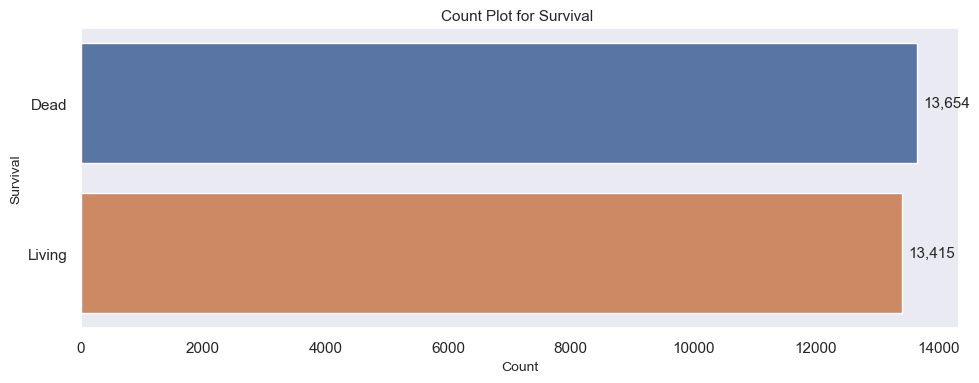

In [6]:
# remove rows where Survival is NaN
df = df.dropna(subset=['Survival'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

# plot
uv.plot_count(df, ['Survival'], fig_size=(10, 4))

#### Unwanted Labels

In [7]:
# remove unwanted labels
removeCols = df_label.column.to_list()

### Ordinal Plots & Engineering

#### Ordinal: Heapmap

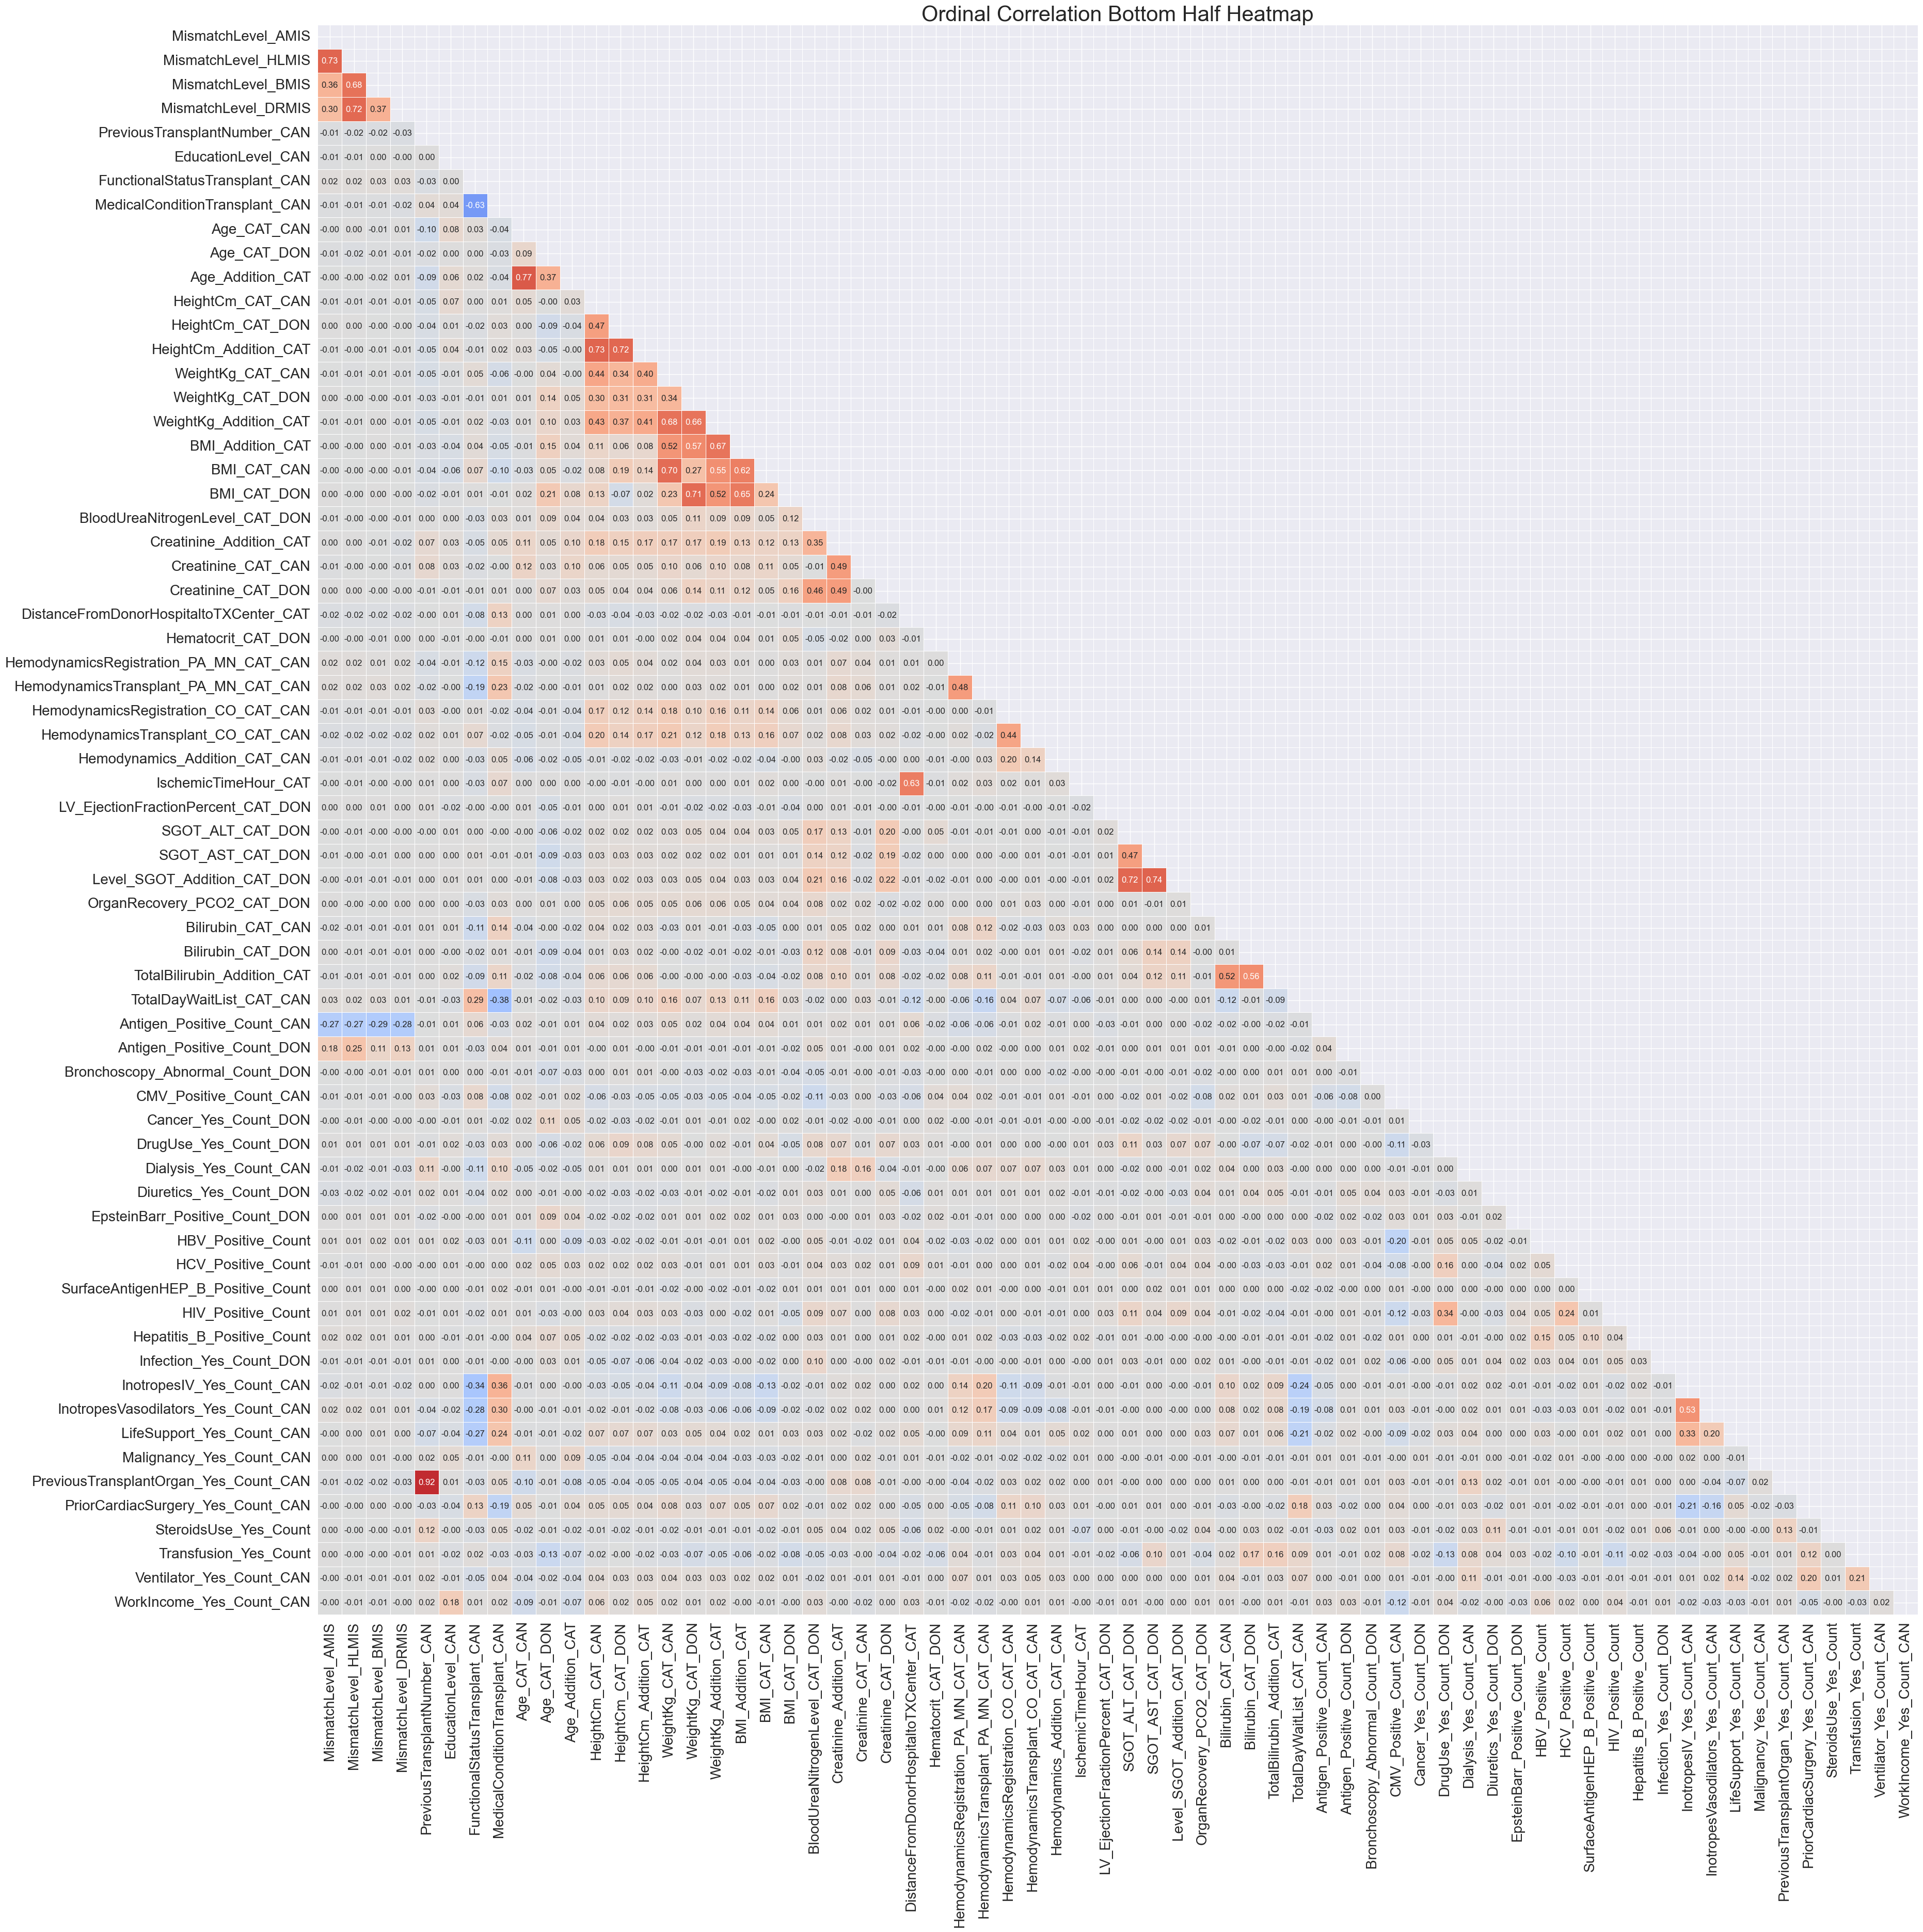

In [8]:
# compute the correlation matrix
corr_matrix = df[df_ordinal.column.to_list()].corr(method='spearman')
# create a mask for the UPPER triangle  
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

# display options
plt.figure(figsize=(40,40))
plt.title("Ordinal Correlation Bottom Half Heatmap", fontsize=30)
plt.xticks(fontsize=20)  # font size for x-ticks
plt.yticks(fontsize=20)  # font size for y-ticks
# plot the BOTTOM half (lower triangle + diagonal)  
sns.heatmap(corr_matrix,  
            mask=mask,  # hide the upper triangle  
            annot=True,  
            cmap='coolwarm',  
            vmin=-1, vmax=1,  
            linewidths=0.5, fmt=".2f", cbar=False)  
plt.show()

#### Ordinal Display
- The ordinal features with Spearman correlation below indicate strong to very moderatly strong positive monotonic relationships between the respective variable pairs 
    - Very Strong Associations (|r| ≥ 0.7)
    - Moderate-Strong Associations (0.5 ≤ |r| < 0.7)

In [9]:
# threshold value
threshold = 0.5
# identify upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# find feature columns with correlation greater than 0.7
to_drop = [column for column in upper.columns if any(np.abs(upper[column]) > threshold)]

# display
print(f"Strong correlation: {sorted(to_drop)}\n")
# ordinal correlation: re-check
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Strong correlation: ['Age_Addition_CAT', 'BMI_Addition_CAT', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'HeightCm_Addition_CAT', 'InotropesVasodilators_Yes_Count_CAN', 'IschemicTimeHour_CAT', 'Level_SGOT_Addition_CAT_DON', 'MedicalConditionTransplant_CAN', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantOrgan_Yes_Count_CAN', 'TotalBilirubin_Addition_CAT', 'WeightKg_Addition_CAT']

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:
Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_HLMIS and MismatchLevel_BMIS: 0.677
Correlation between MismatchLevel_HLMIS and MismatchLevel_DRMIS: 0.718
Correlation between PreviousTransplantNumber_CAN and PreviousTransplantOrgan_Yes_Count_CAN: 0.925
Correlation between FunctionalStatusTransplant_CAN and MedicalConditionTransplant_CAN: -0.628
Correlation between Age_CAT_CAN and Age_Addition_CAT: 0.767
Correlation between HeightCm_CAT_CAN and HeightCm_Addition_CAT

#### Engineer: MismatchLevel

In [10]:
features = uf.get_feature_list(df, 'MismatchLevel')

                       count      mean       std  min  25%  50%  75%  max
MismatchLevel_AMIS   27069.0  1.576231  0.729327  0.0  1.0  2.0  2.0  3.0
MismatchLevel_BMIS   27069.0  1.806347  0.598162  0.0  1.0  2.0  2.0  3.0
MismatchLevel_DRMIS  27069.0  1.622631  0.699389  0.0  1.0  2.0  2.0  3.0
MismatchLevel_HLMIS  27069.0  4.841959  1.208987  0.0  4.0  5.0  6.0  7.0

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [11]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_BMIS and MismatchLevel_HLMIS: 0.677
Correlation between MismatchLevel_DRMIS and MismatchLevel_HLMIS: 0.718


In [12]:
# append to removeCols
removeCols.extend(features)

# combine
df['MismatchLevel_Addition'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['MismatchLevel_Addition'])
df_both = uf.insert_into_dataframe(df_both, ['MismatchLevel_Addition'])
# display
uf.category_contingency_survival(df, 'MismatchLevel_Addition')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,11.0,15.0,26.0,42.307692,57.692308
2.0,49.0,52.0,101.0,48.514851,51.485149
4.0,310.0,364.0,674.0,45.994065,54.005935
6.0,1363.0,1385.0,2748.0,49.599709,50.400291
8.0,3214.0,3138.0,6352.0,50.598237,49.401763
10.0,4679.0,4582.0,9261.0,50.523702,49.476298
12.0,2927.0,2762.0,5689.0,51.450167,48.549833
13.0,1.0,2.0,3.0,33.333333,66.666667
14.0,1.0,1.0,2.0,50.000000,50.000000
15.0,0.0,2.0,2.0,0.000000,100.000000


#### Engineer: Inotropes

In [13]:
features = uf.get_feature_list(df, 'Inotropes')

                                       count      mean       std  min  25%  50%  75%   max
InotropesIV_Yes_Count_CAN            27069.0  0.715542  0.818312  0.0  0.0  0.0  1.0   2.0
InotropesVasodilators_Yes_Count_CAN  27069.0  4.006391  4.065591  0.0  0.0  5.0  9.0  10.0

:::: NaN Count:
InotropesIV_Yes_Count_CAN              0
InotropesVasodilators_Yes_Count_CAN    0


In [14]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between InotropesIV_Yes_Count_CAN and InotropesVasodilators_Yes_Count_CAN: 0.532


In [15]:
# append to removeCols
removeCols.extend(features)

# combine
df['Inotropes_Yes_Count_Addition_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Inotropes_Yes_Count_Addition_CAN'])
df_can = uf.insert_into_dataframe(df_can, ['Inotropes_Yes_Count_Addition_CAN'])
# display
uf.category_contingency_survival(df, 'Inotropes_Yes_Count_Addition_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,5124.0,4500.0,9624.0,53.241895,46.758105
1,785.0,905.0,1690.0,46.449704,53.550296
2,429.0,440.0,869.0,49.367089,50.632911
3,26.0,43.0,69.0,37.681159,62.318841
4,213.0,220.0,433.0,49.191686,50.808314
5,1233.0,1507.0,2740.0,45.000000,55.000000
6,1333.0,1485.0,2818.0,47.303052,52.696948
7,658.0,686.0,1344.0,48.958333,51.041667
8,88.0,79.0,167.0,52.694611,47.305389
9,197.0,160.0,357.0,55.182073,44.817927


#### Ordinal Remove

In [16]:
# append to removeCols list
removeCols.extend(find_feature('Bilirubin_CAT', df.columns.to_list()))
removeCols.extend(find_feature('BMI_', df.columns.to_list()))
removeCols.extend(find_feature('PreviousTransplantNumber_CAN', df.columns.to_list())) 
removeCols.extend(find_feature('FunctionalStatusTransplant_CAN', df.columns.to_list()))
removeCols.extend(find_feature('Age_CAT', df.columns.to_list()))
removeCols.extend(find_feature('HeightCm_CAT', df.columns.to_list()))
removeCols.extend(find_feature('WeightKg_CAT', df.columns.to_list()))
removeCols.extend(find_feature('DistanceFromDonorHospitaltoTXCenter_CAT', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_ALT_CAT_DON', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_AST_CAT_DON', df.columns.to_list()))

# remove features
df, df_ordinal, df_nominal, df_can, df_don, df_both = HouseKeeping(df, removeCols, df_ordinal, df_nominal, df_can, df_don, df_both, display=True)

Remove 22 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 9 row(s) from df_can DataFrame.
Remove 7 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.

Removed Features: ['Age_CAT_CAN', 'Age_CAT_DON', 'BMI_Addition_CAT', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'FunctionalStatusTransplant_CAN', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'InotropesIV_Yes_Count_CAN', 'InotropesVasodilators_Yes_Count_CAN', 'LengthOfStay', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'SGOT_ALT_CAT_DON', 'SGOT_AST_CAT_DON', 'TransplantSurvivalDay', 'WeightKg_CAT_CAN', 'WeightKg_CAT_DON']

Total Row(s) & Column(s) Before Removing Column(s): 27,069 & columns: 119
Total Row(s) & Column(s) After Removing Column(s): 27,069 & columns: 95


#### Ordinal Association Testing

In [17]:
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:


In [18]:
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[(mwutDF.p_value >= 0.05)]

,column1,column2,U_statistic,p_value
936,HCV_Positive_Count,PreviousTransplantOrgan_Yes_Count_CAN,366342668.5,0.968037
89,Age_Addition_CAT,HeightCm_Addition_CAT,366595467.0,0.883822
90,Age_Addition_CAT,WeightKg_Addition_CAT,366040820.0,0.836708
1029,Ventilator_Yes_Count_CAN,WorkIncome_Yes_Count_CAN,366037837.0,0.794706
132,HeightCm_Addition_CAT,WeightKg_Addition_CAT,365810818.5,0.724715
831,Cancer_Yes_Count_DON,SurfaceAntigenHEP_B_Positive_Count,366230182.0,0.722806
980,Infection_Yes_Count_DON,LifeSupport_Yes_Count_CAN,367045818.0,0.684453
58,MedicalConditionTransplant_CAN,IschemicTimeHour_CAT,365556788.0,0.636618
265,Creatinine_Addition_CAT,Level_SGOT_Addition_CAT_DON,367557441.5,0.487121
788,Bronchoscopy_Abnormal_Count_DON,HBV_Positive_Count,365376298.5,0.404083


##### There are associations, but they are different features representing something different.

#### Ordinal Datatype Update

In [19]:
# change datatype to category
df = uf.convert_to_category(df, df_ordinal.column.to_list(), ordered=True)

### Nominal Plots & Engineering

#### Nominal Chi2 Test & Cramer V

In [20]:
# hypothesis testing
nominalDF = usf.multi_independence_category(df, df_nominal.column.to_list())
# display
nominalDF[(nominalDF.p_value <= 0.05) & (nominalDF.cramer_v > .5)]

,column1,column2,chi2,p_value,cramer_v
131,AntiHypertensive_DON,Vasodilators_DON,28136.369867,0.0,0.720913
938,DeceasedRetyped_DON,CrossMatchDone,28063.772389,0.0,0.719982
189,PrimaryDiagnosisType_CAN,CigaretteUse_CAN,27341.069852,0.0,0.710651
1028,PulmonaryCatheter_DON,HeparinManagement_DON,26027.749339,0.0,0.693373
1008,ThyroxineT4_DON,PulmonaryCatheter_DON,24604.567632,0.0,0.674150
122,AntiHypertensive_DON,ThyroxineT4_DON,24410.728886,0.0,0.671490
992,TriiodothyronineT3_DON,ThyroxineT4_DON,24310.633645,0.0,0.670111
1032,PulmonaryCatheter_DON,InsulinManagement_DON,24182.431910,0.0,0.668342
167,ArginnieManagement_DON,PulmonaryCatheter_DON,23767.879105,0.0,0.662589
1018,ThyroxineT4_DON,InsulinManagement_DON,23763.734507,0.0,0.662531


#### Nominal Datatype Update

In [21]:
# change datatype to category
df = uf.convert_to_category(df, df_nominal.column.to_list())

### Dummy Encoding

In [22]:
# shape
print(f"Shape before encoding: {df.shape}")
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape after encoding: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')

Shape before encoding: (27069, 95)
Shape after encoding: (27069, 203)


### Split Dataset

In [23]:
from sklearn.model_selection import train_test_split

# print shape
print(f"Encode & Heart Dataset Rows before split: {df_dummy.shape[0]:,} & Columns: {df_dummy.shape[1]:,}")

# split X & y
X = df_dummy.drop(columns = 'Survival')
y = df_dummy.Survival

# mapping values
y = y.map({'Dead': False, 'Living': True})
# print
print(f"Dead: {False} & Living: {True}")

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Encode & Heart Dataset Rows before split: 27,069 & Columns: 203
Dead: False & Living: True


### Scale

In [24]:
from sklearn.preprocessing import MinMaxScaler

# determine features to scale
scaleListCols = df_ordinal.column.to_list()
                     
# initialize MinMaxScaler
scale = MinMaxScaler()

# fit
fitScale = scale.fit(X_train[scaleListCols])

# transform
X_train[scaleListCols] = fitScale.transform(X_train[scaleListCols])
X_test[scaleListCols] = fitScale.transform(X_test[scaleListCols])

### K Best Feature Selection

In [25]:
# inialized 
p_value = 0.05 
# apply feature selection
best_feature_df = ufs.select_kbest_best_function(X_train, y_train, K='all')
# capture features >= .05
removeCols = best_feature_df['Feature'][best_feature_df.p_value >= p_value].to_list()
# print
print(f"\nFeature(s) count to be removed: {len(removeCols)}")
# remove features
X_train = X_train.drop(columns=removeCols)
X_test = X_test.drop(columns=removeCols)
# print
print(f"\nNew Shape Train: {X_train.shape}")
print(f"New Shape Test: {X_test.shape}")

Best Scoring Function: f_classif

Feature(s) count to be removed: 71

New Shape Train: (21655, 131)
New Shape Test: (5414, 131)


In [26]:
# message for dataframe
msg = f"2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 {p_value} removed - SWAP"

### RandomForestClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
# # function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
# from sklearn.utils.class_weight import compute_class_weight

# # the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# define the search space
search_space = parms.rfc_search_space()

# Initialize Model with class weights
rfc_param = {'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
Model = RandomForestClassifier(**rfc_param)

# Hyper-Parameter tuning
rfc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, custom_scorer='f1', n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = rfc_fit

Best parameters found: OrderedDict([('class_weight', 'balanced'), ('max_depth', 10), ('max_features', 'sqrt'), ('min_samples_split', 10), ('n_estimators', 415)])
Best score achieved: 0.8578051716783562

Current Model Parameters:
 RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=415,
                       random_state=1776)


In [28]:
print(Model)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=415,
                       random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.72      0.83     10923
        True       0.77      0.98      0.86     10732

    accuracy                           0.85     21655
   macro avg       0.87      0.85      0.85     21655
weighted avg       0.87      0.85      0.84     21655



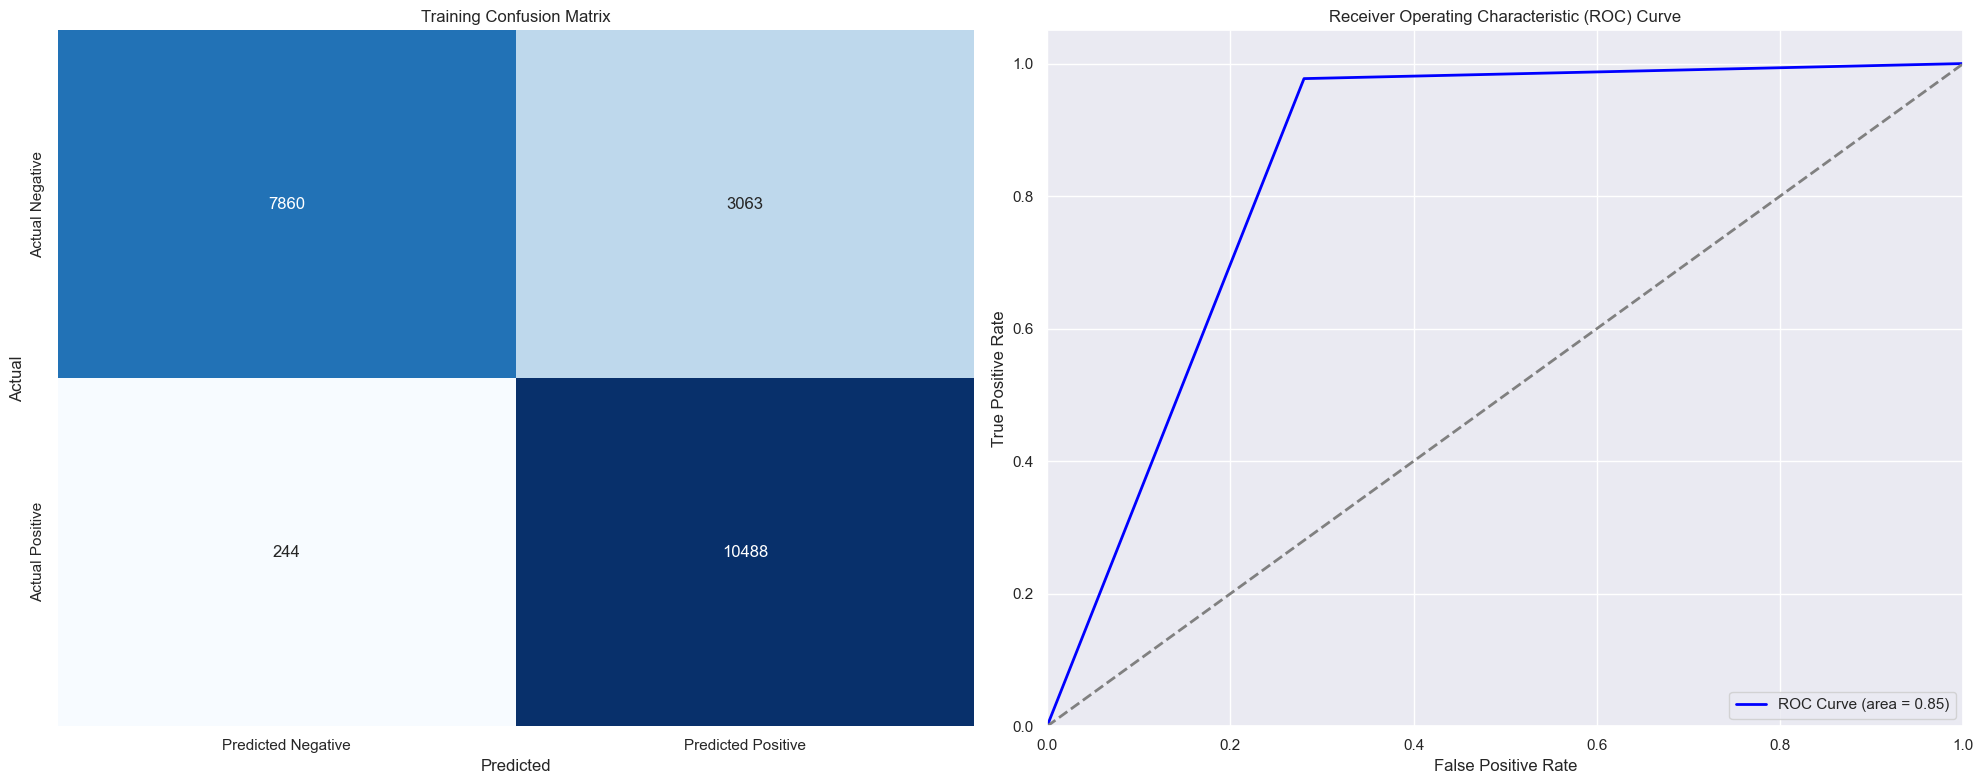

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423


In [29]:
# initialize variables
algorithm = 'RandomForestClassifier'
desc = f'{algorithm} - {msg}'
model = 'rfc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=None, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.70      0.81      2731
        True       0.76      0.97      0.85      2683

    accuracy                           0.83      5414
   macro avg       0.86      0.84      0.83      5414
weighted avg       0.86      0.83      0.83      5414



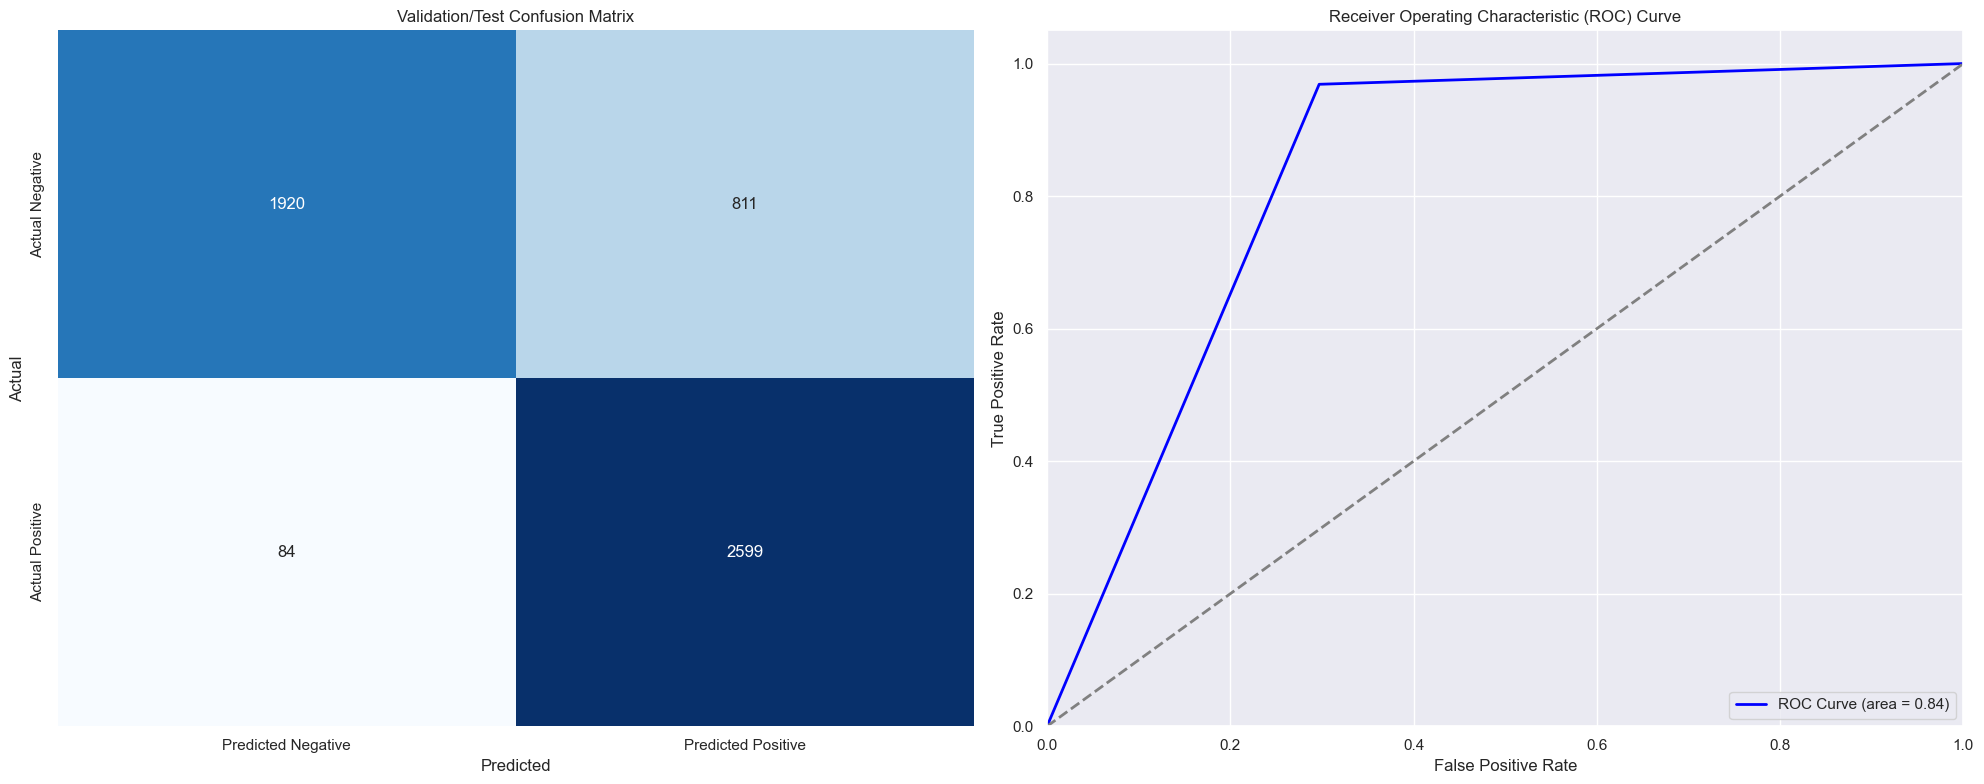

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865


In [30]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type,  metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

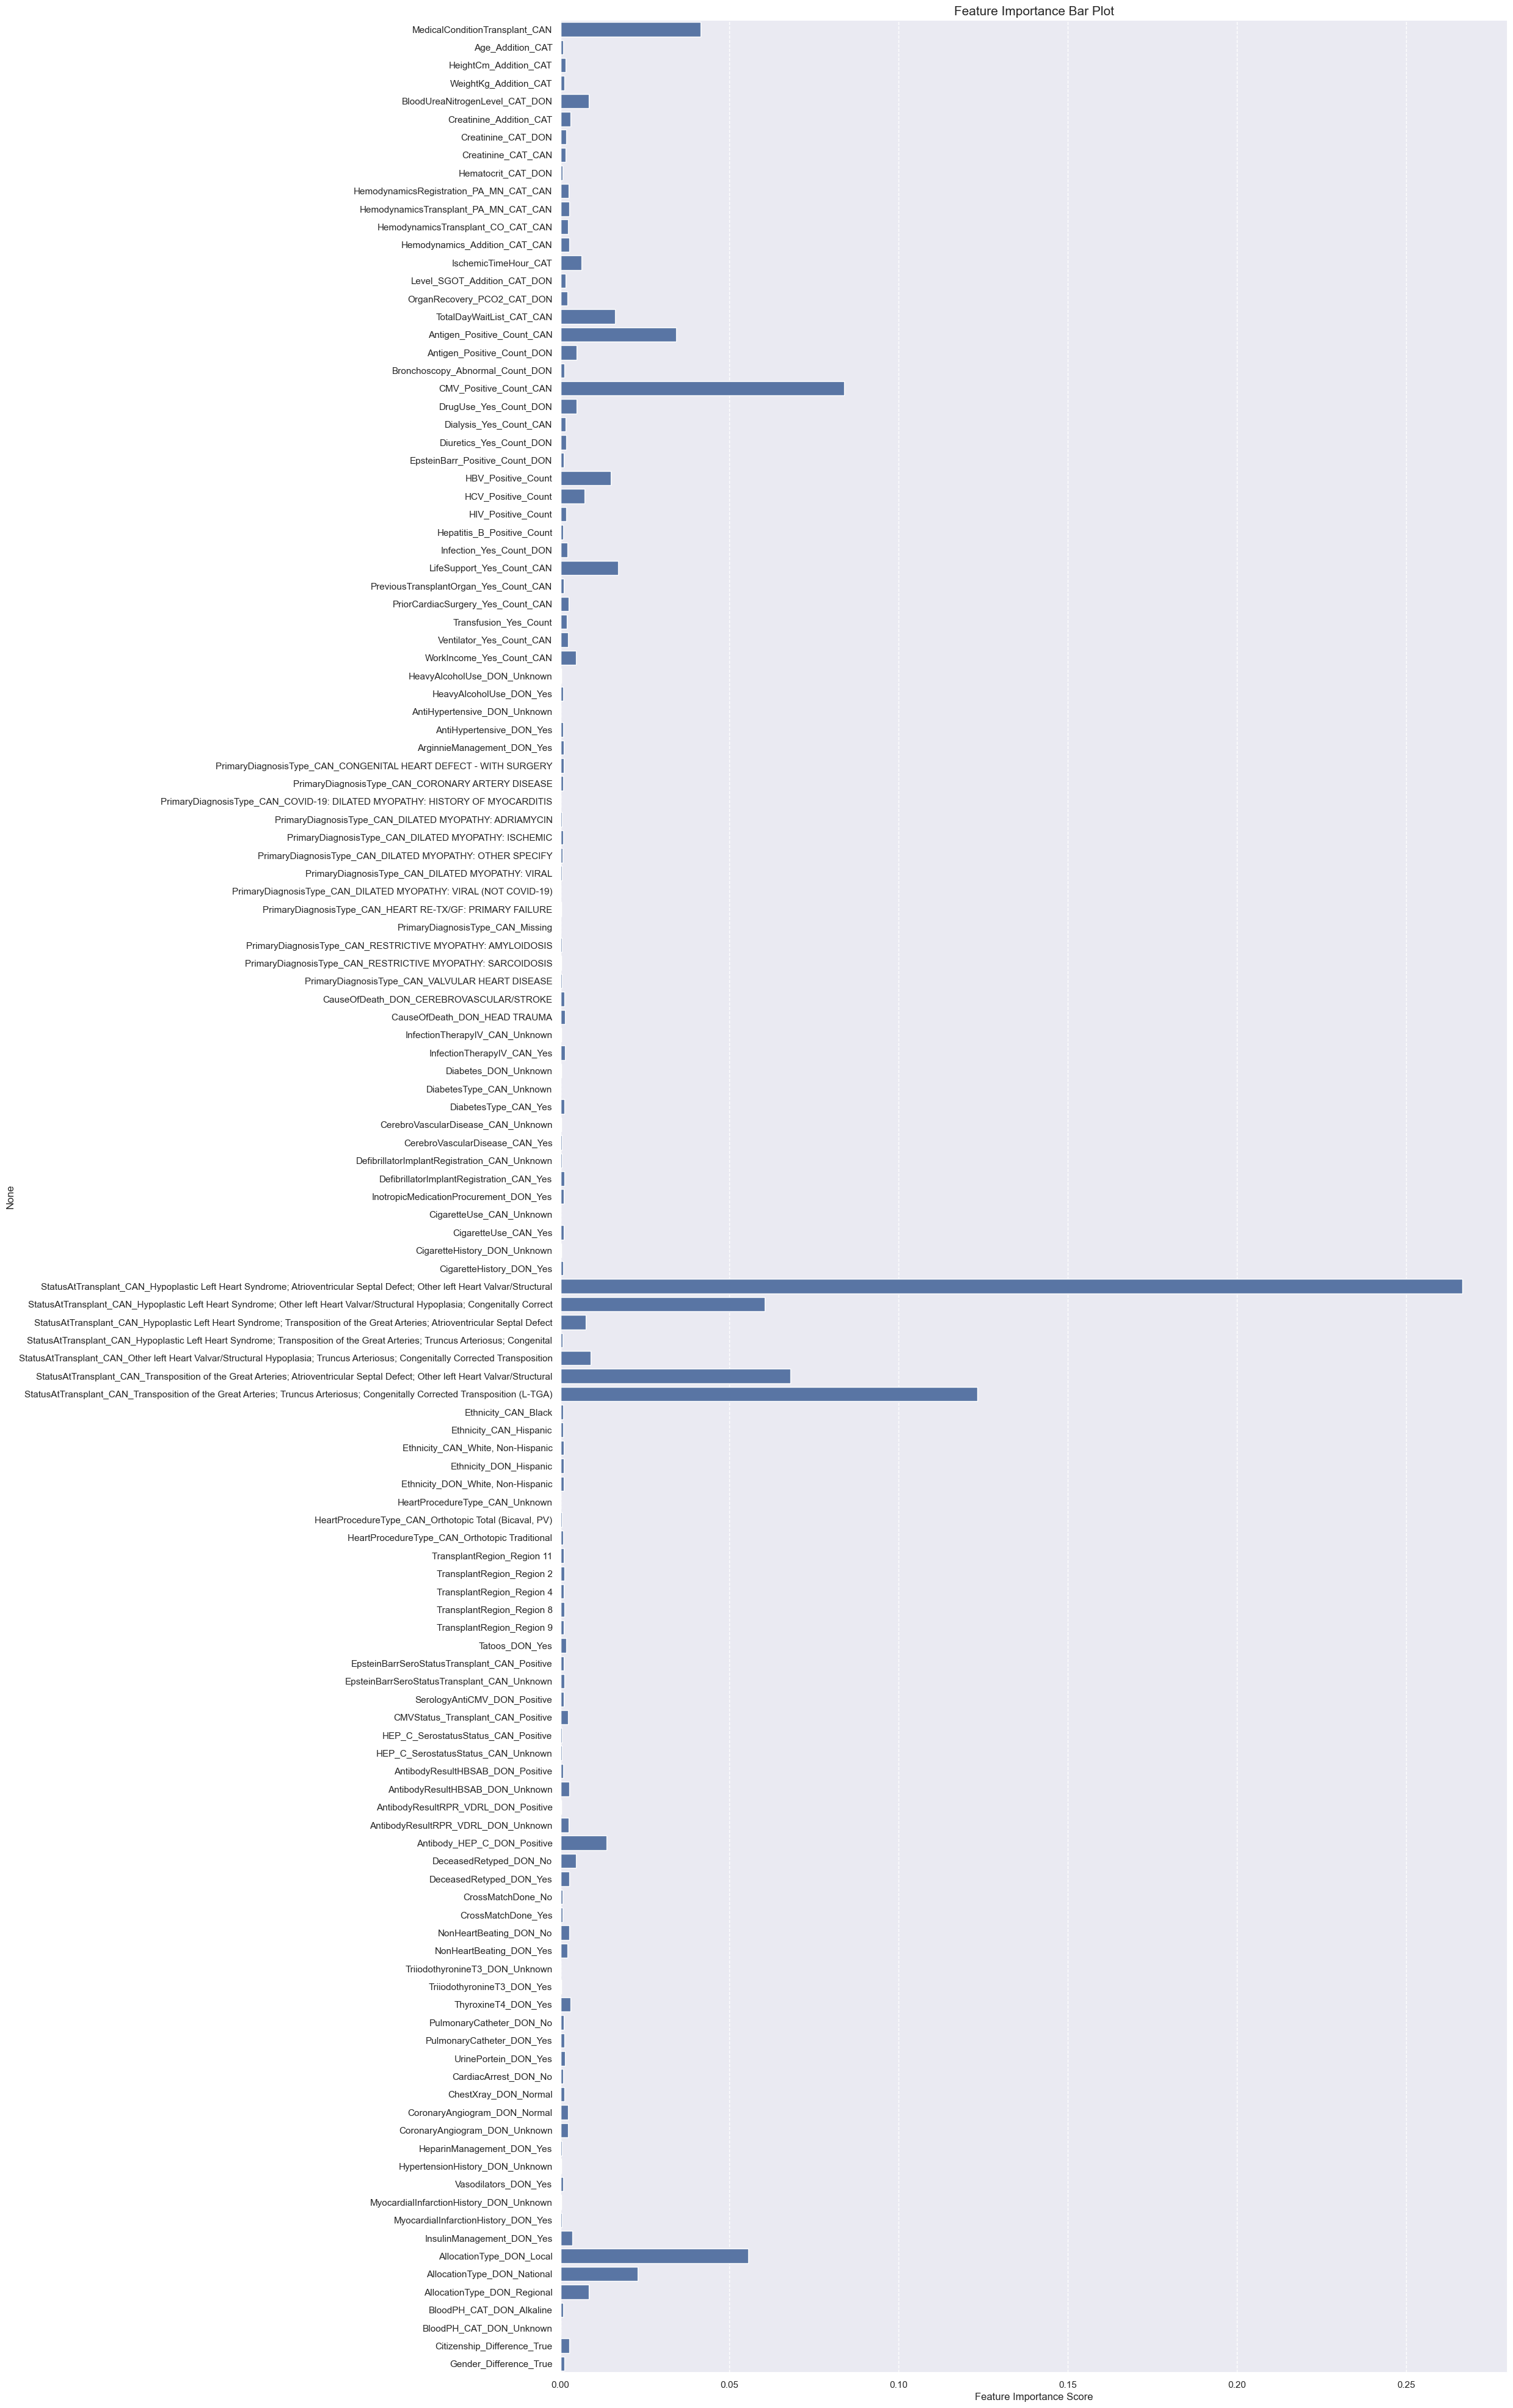

In [31]:
df_rfc = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [32]:
df_rfc.sort_values(by='Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.266584
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.123310
CMV_Positive_Count_CAN,0.083891
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.068017
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.060332
AllocationType_DON_Local,0.055559
MedicalConditionTransplant_CAN,0.041380
Antigen_Positive_Count_CAN,0.034167
AllocationType_DON_National,0.022742
LifeSupport_Yes_Count_CAN,0.017068


### LogisticRegression

In [33]:
# import library
from sklearn.linear_model import LogisticRegression

# define the search space
search_space = parms.lrc_search_space()

# Base Model
lrc_param = {'max_iter':10000, 'random_state': RANDOM_STATE, 'solver': 'saga', 'penalty': 'elasticnet'}

# instantiate LogisticRegression Classifier
Model = LogisticRegression(**lrc_param)

# Hyper-Parameter tuning
lrc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, 'f1', n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = lrc_fit

Best parameters found: OrderedDict([('C', 0.21929817299515758), ('class_weight', 'balanced'), ('l1_ratio', 1.0)])
Best score achieved: 0.8558841025454562

Current Model Parameters:
 LogisticRegression(C=0.21929817299515758, class_weight='balanced', l1_ratio=1.0,
                   max_iter=10000, penalty='elasticnet', random_state=1776,
                   solver='saga')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.71      0.82     10923
        True       0.77      0.97      0.86     10732

    accuracy                           0.84     21655
   macro avg       0.86      0.84      0.84     21655
weighted avg       0.86      0.84      0.84     21655



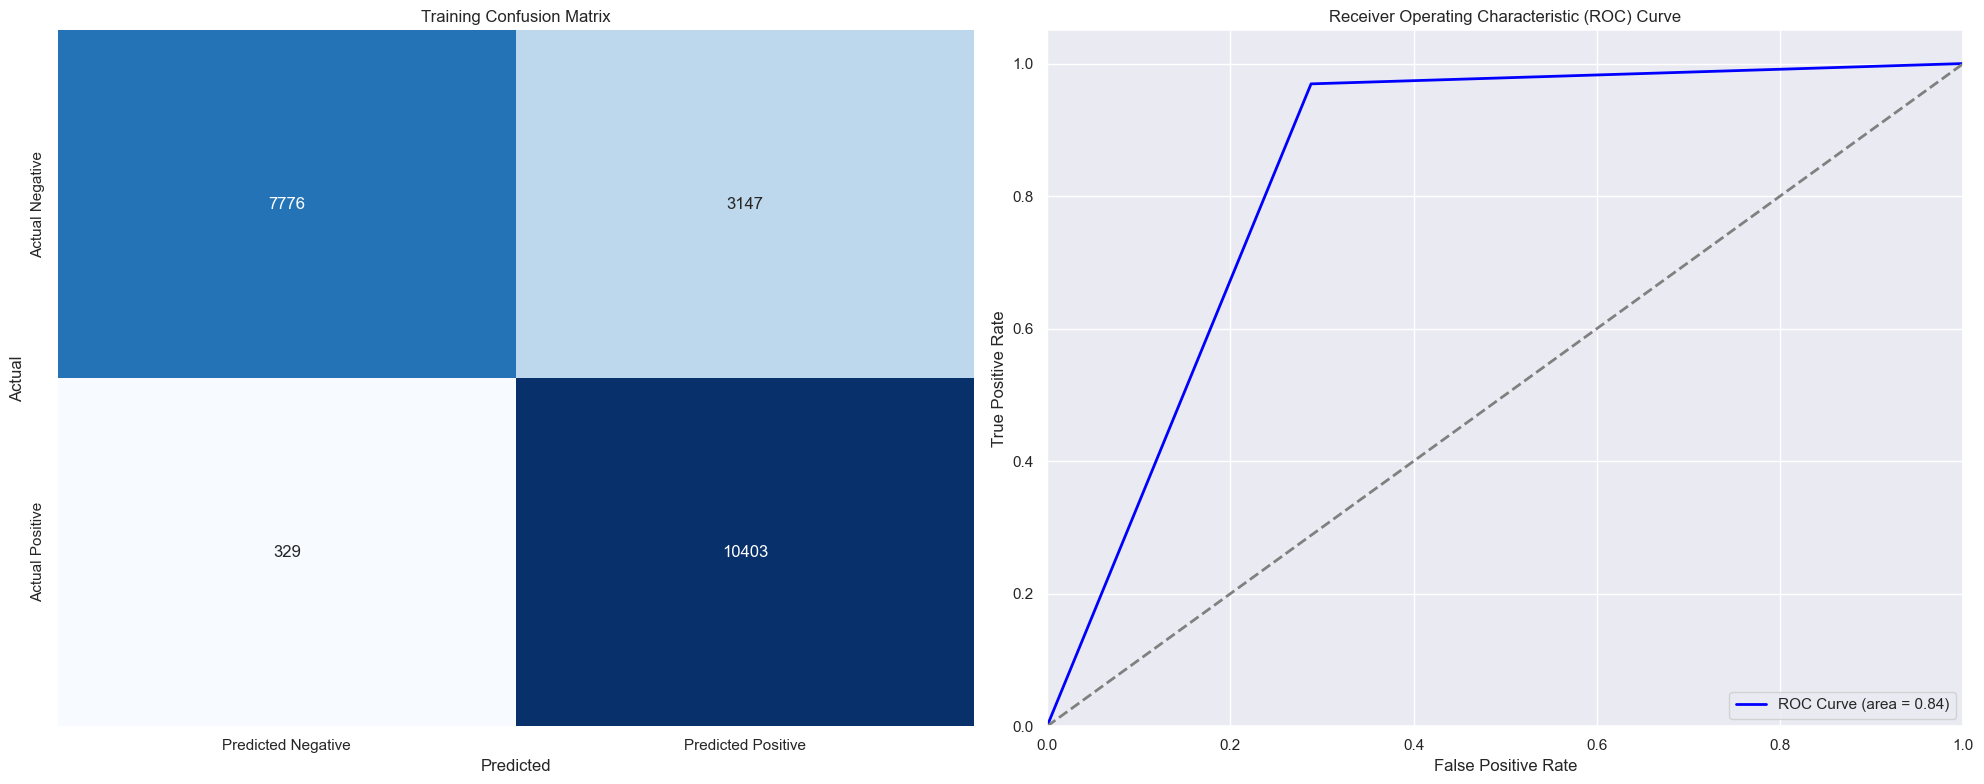

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618


In [34]:
# initialize variables
algorithm = 'LogisticRegression'
desc = f'{algorithm} - {msg}'
model = 'lrc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.70      0.81      2731
        True       0.76      0.97      0.85      2683

    accuracy                           0.84      5414
   macro avg       0.86      0.84      0.83      5414
weighted avg       0.86      0.84      0.83      5414



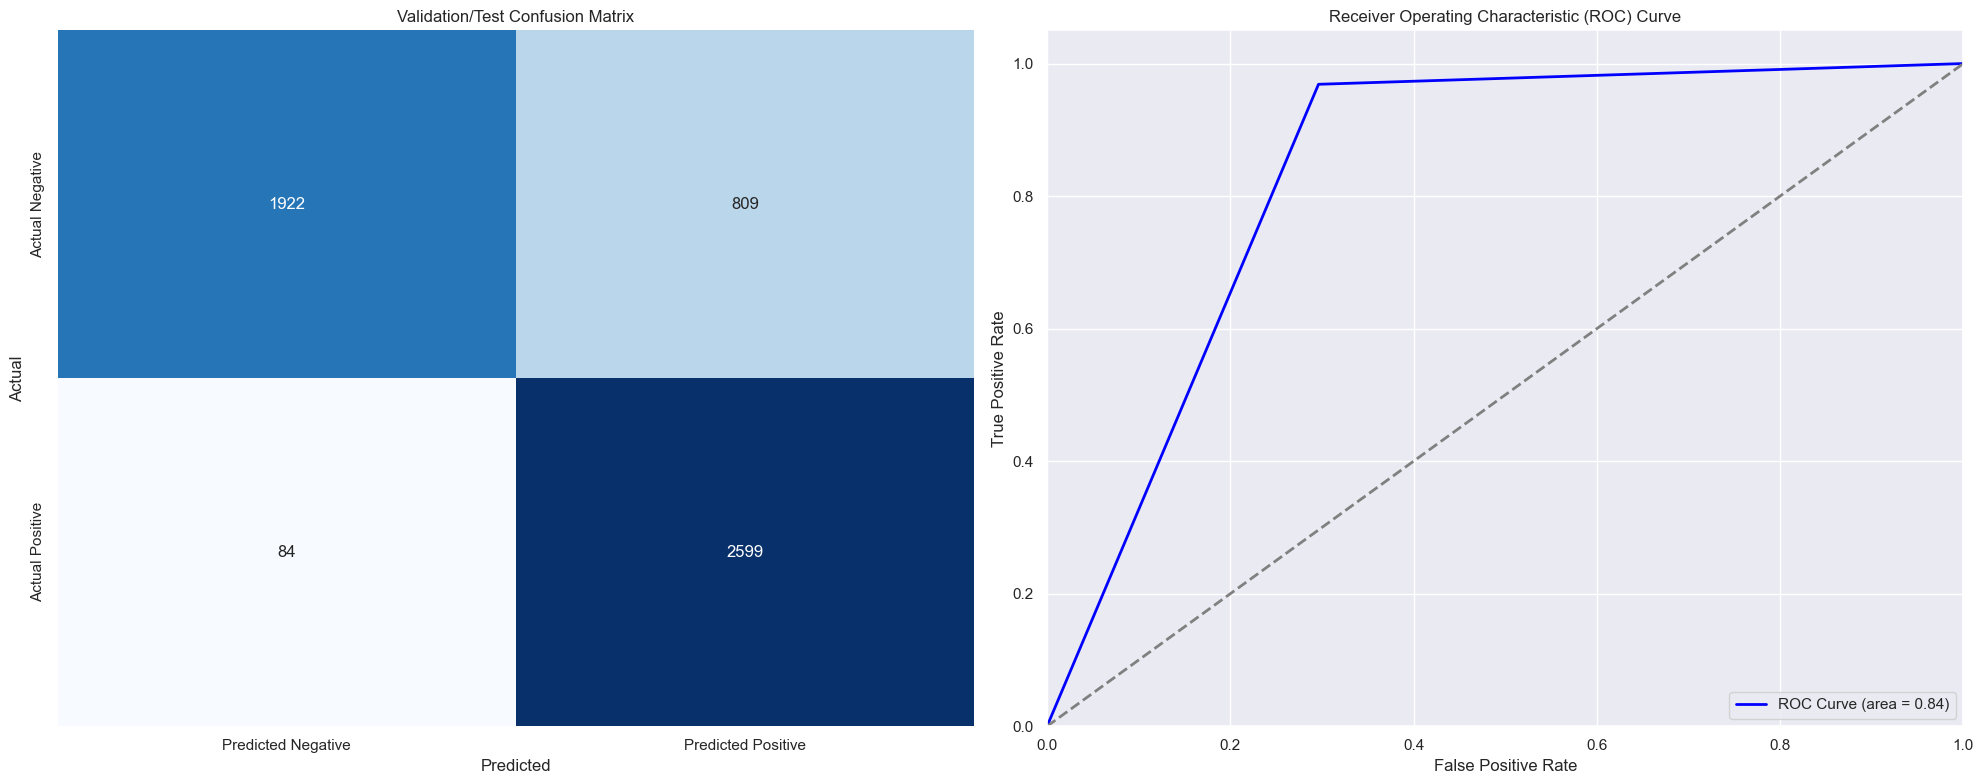

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232


In [35]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

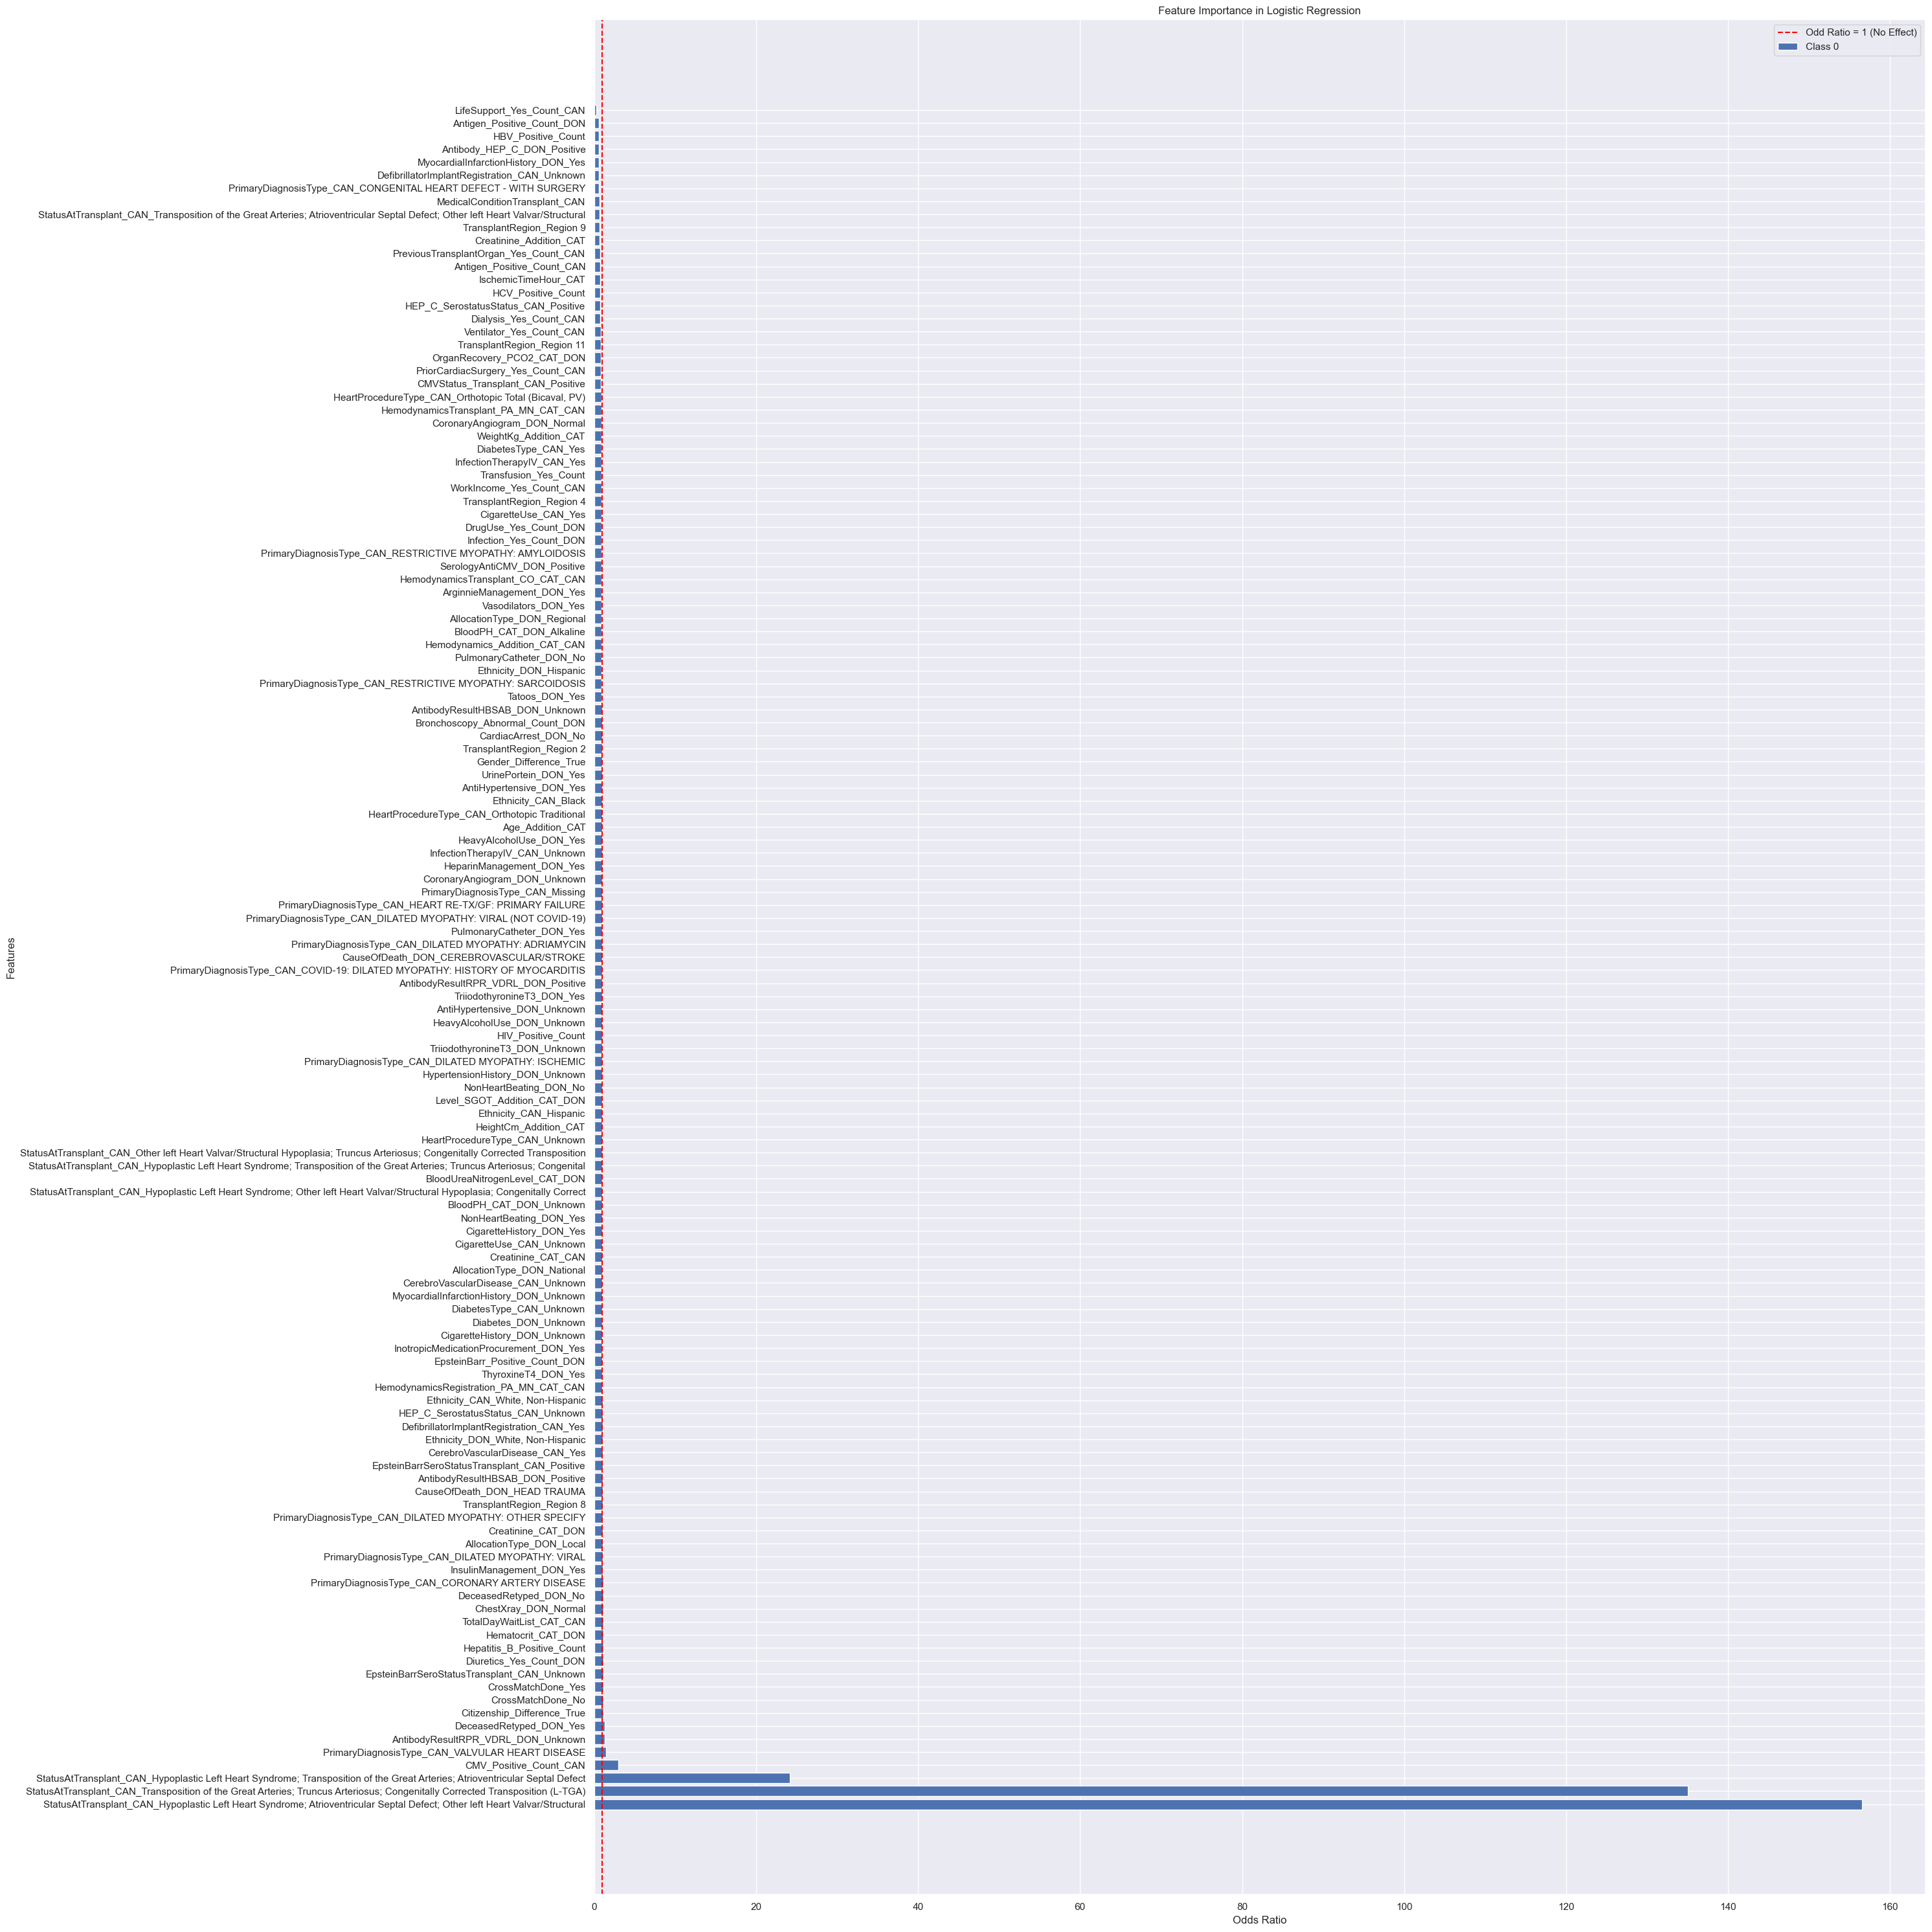

In [36]:
df_lrc = umf.logistic_feature_importance(Model, figsize=(30,30), fontsize=6)

In [37]:
df_lrc.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Description,Odd Ratio,Percentage Change in Odds,Probability,Class
0,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,5.053255,Increase in the log-odds of the Positive Class,156.531190,15553.118987,0.993652,Class 0
1,StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),4.905593,Increase in the log-odds of the Positive Class,135.042962,13404.296205,0.992649,Class 0
2,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,3.184734,Increase in the log-odds of the Positive Class,24.160865,2316.086518,0.960256,Class 0
3,CMV_Positive_Count_CAN,1.093424,Increase in the log-odds of the Positive Class,2.984477,198.447681,0.749026,Class 0
4,PrimaryDiagnosisType_CAN_VALVULAR HEART DISEASE,0.367409,Increase in the log-odds of the Positive Class,1.443988,44.398807,0.590833,Class 0
5,AntibodyResultRPR_VDRL_DON_Unknown,0.288963,Increase in the log-odds of the Positive Class,1.335042,33.504196,0.571742,Class 0
6,DeceasedRetyped_DON_Yes,0.246695,Increase in the log-odds of the Positive Class,1.279789,27.978891,0.561363,Class 0
7,Citizenship_Difference_True,0.172574,Increase in the log-odds of the Positive Class,1.188360,18.835965,0.543037,Class 0
8,CrossMatchDone_No,0.166103,Increase in the log-odds of the Positive Class,1.180695,18.069483,0.541431,Class 0
9,CrossMatchDone_Yes,0.160937,Increase in the log-odds of the Positive Class,1.174612,17.461153,0.540148,Class 0


### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [38]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the search space
search_space = parms.xgbc_search_space(scale_pos_weight)

# Base Model
xgb_param = {'random_state': RANDOM_STATE}

# instantiate XGB Classifier
Model = XGBClassifier(**xgb_param)

# Hyper-Parameter tuning
xgb_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, 'f1', n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = xgb_fit

Best parameters found: OrderedDict([('colsample_bytree', 0.8708451477080826), ('gamma', 3.0210975750649767), ('learning_rate', 0.013003101159185708), ('max_depth', 10), ('n_estimators', 320), ('scale_pos_weight', 1.0121841871079214), ('subsample', 0.7956737640282101)])
Best score achieved: 0.862083150916076

Current Model Parameters:
 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8708451477080826, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=3.0210975750649767,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013003101159185708,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monot

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.73      0.84     10923
        True       0.78      0.99      0.87     10732

    accuracy                           0.86     21655
   macro avg       0.88      0.86      0.86     21655
weighted avg       0.89      0.86      0.86     21655



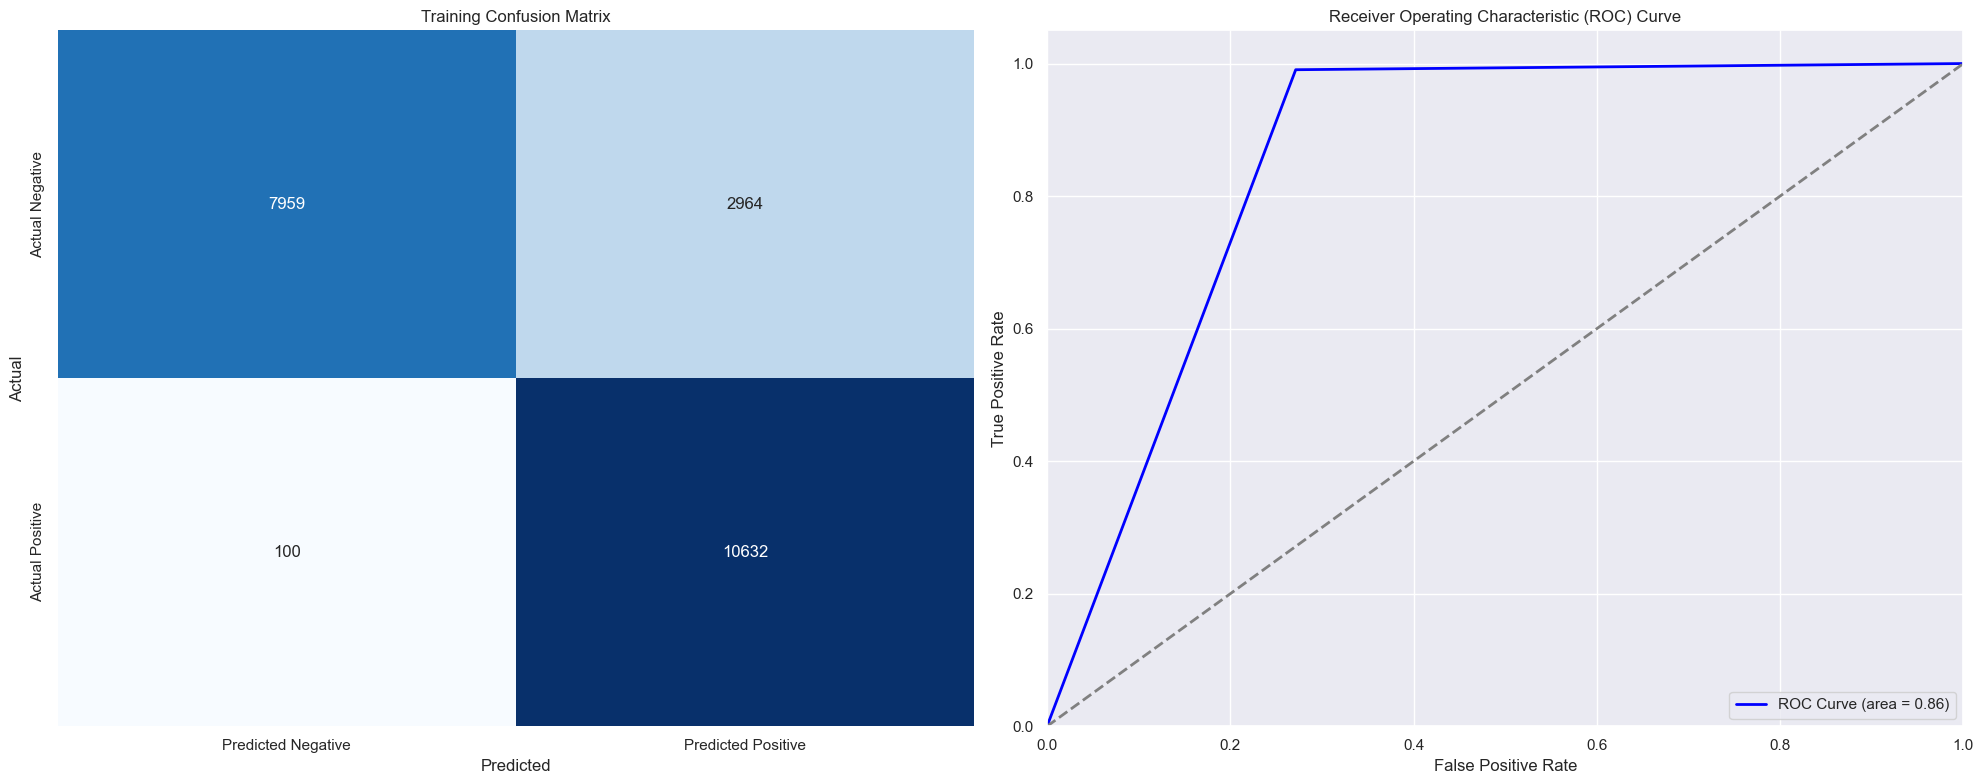

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664


In [39]:
# initialize variables
algorithm = 'XGBClassifier'
desc = f'{algorithm} - {msg}'
model = 'xgb_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.69      0.81      2731
        True       0.76      0.99      0.86      2683

    accuracy                           0.84      5414
   macro avg       0.87      0.84      0.84      5414
weighted avg       0.87      0.84      0.84      5414



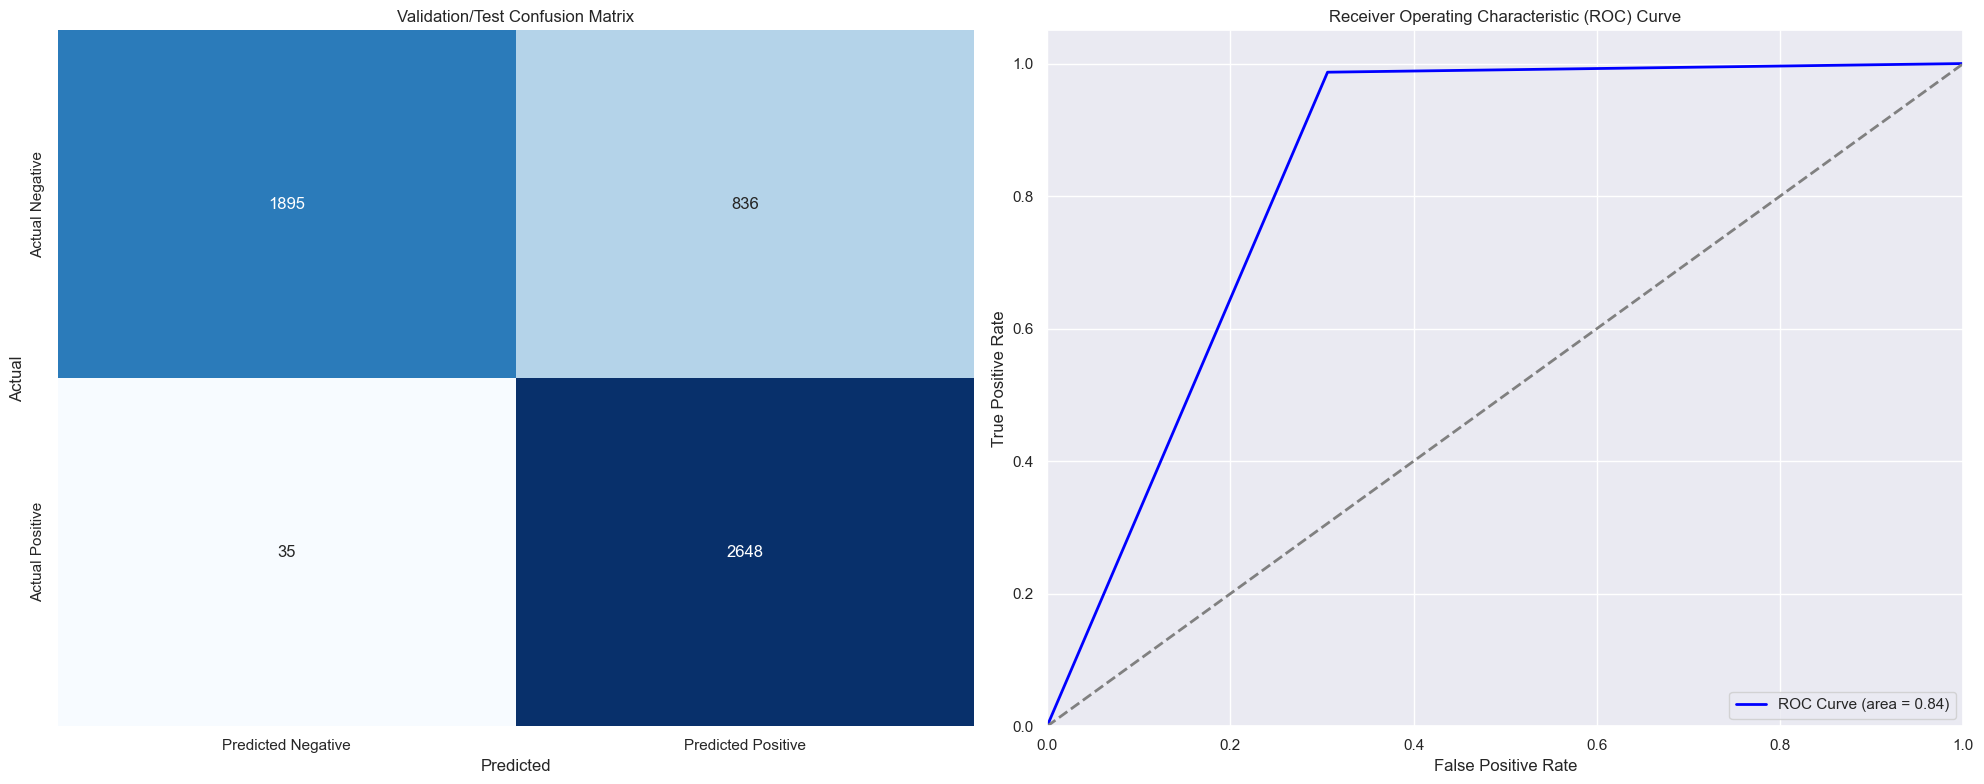

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420


In [40]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

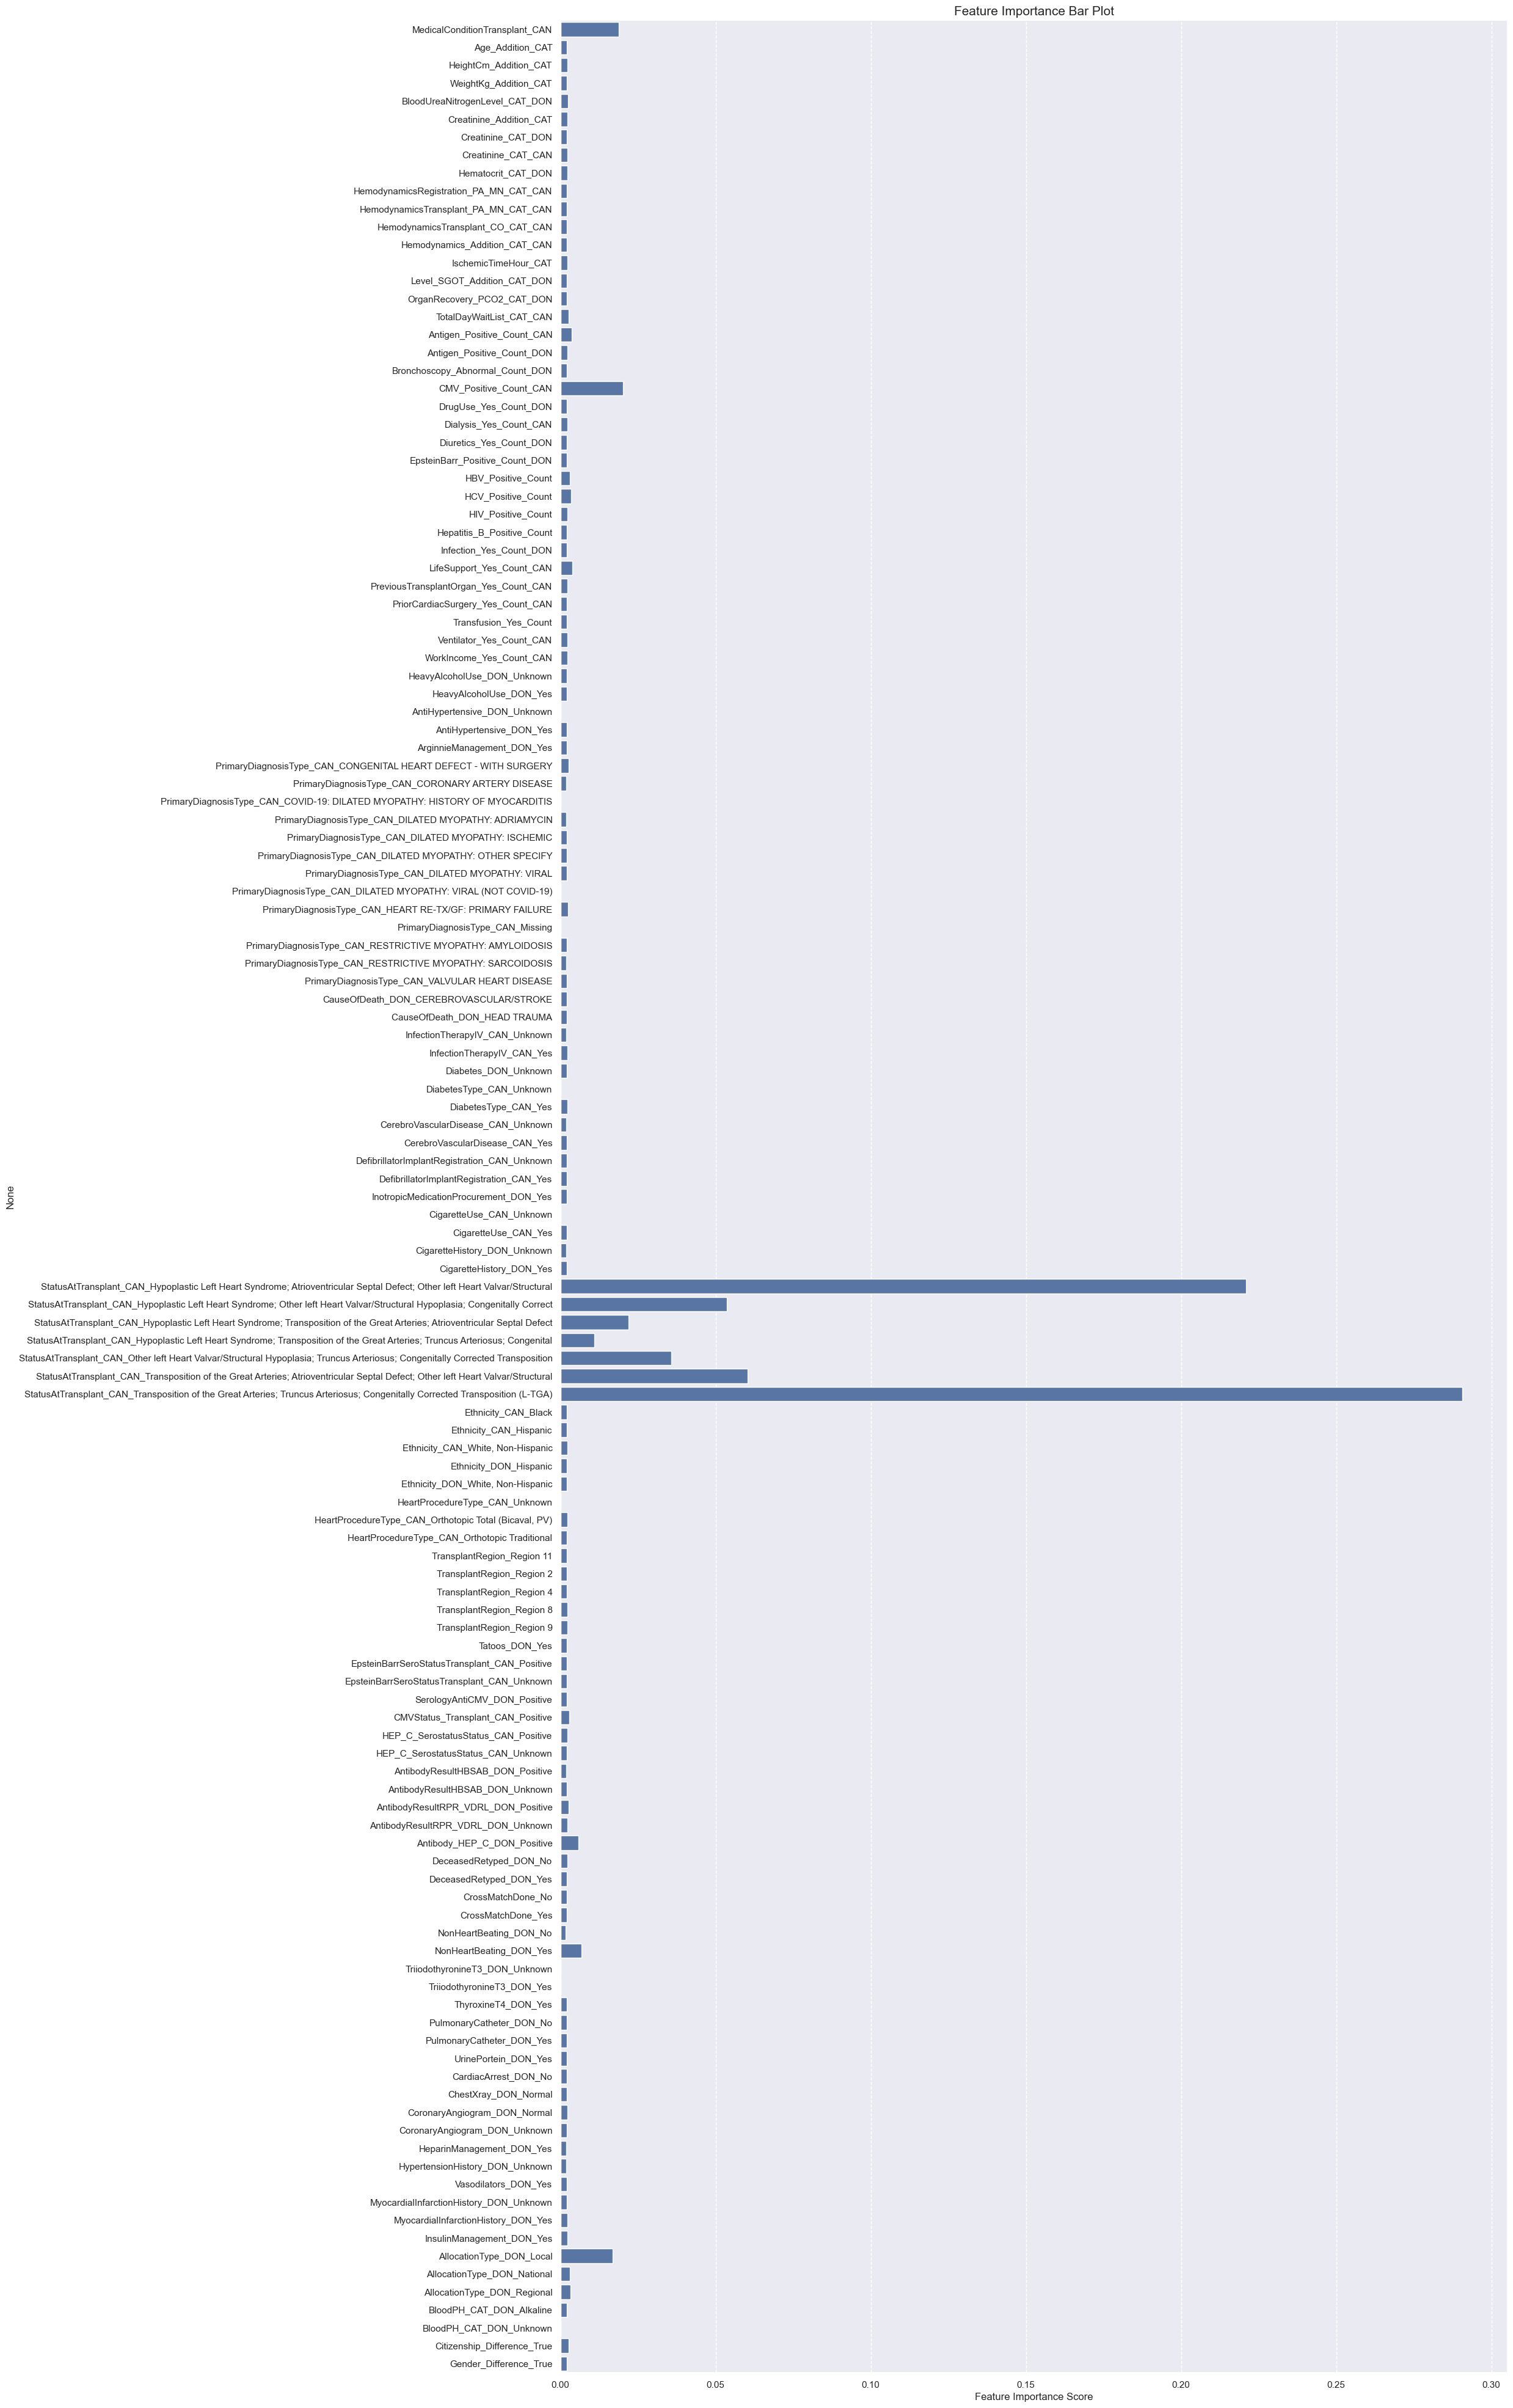

In [41]:
df_xgb = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [42]:
df_xgb.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.290588
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.221009
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.060229
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.053634
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.035712
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.021903
CMV_Positive_Count_CAN,0.020219
MedicalConditionTransplant_CAN,0.018743
AllocationType_DON_Local,0.016890
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital,0.010921


### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [43]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the search space
search_space = parms.knn_search_space()

# create a KNN model
Model = KNeighborsClassifier(n_jobs=-1)

# Hyper-Parameter tuning
knn_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, 'f1', n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = knn_fit

/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), np.int64(20), np.int64(1), np.str_('distance')] before, using random point [np.int64(31), np.int64(12), 1, 'uniform']
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), np.int64(20), np.int64(1), np.str_('distance')] before, using random point [np.int64(37), np.int64(2), 1, 'distance']
  warnings.warn(


Best parameters found: OrderedDict([('leaf_size', 50), ('n_neighbors', 20), ('p', 1), ('weights', 'distance')])
Best score achieved: 0.811569317777141

Current Model Parameters:
 KNeighborsClassifier(leaf_size=50, n_jobs=-1, n_neighbors=20, p=1,
                     weights='distance')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     10923
        True       1.00      1.00      1.00     10732

    accuracy                           1.00     21655
   macro avg       1.00      1.00      1.00     21655
weighted avg       1.00      1.00      1.00     21655



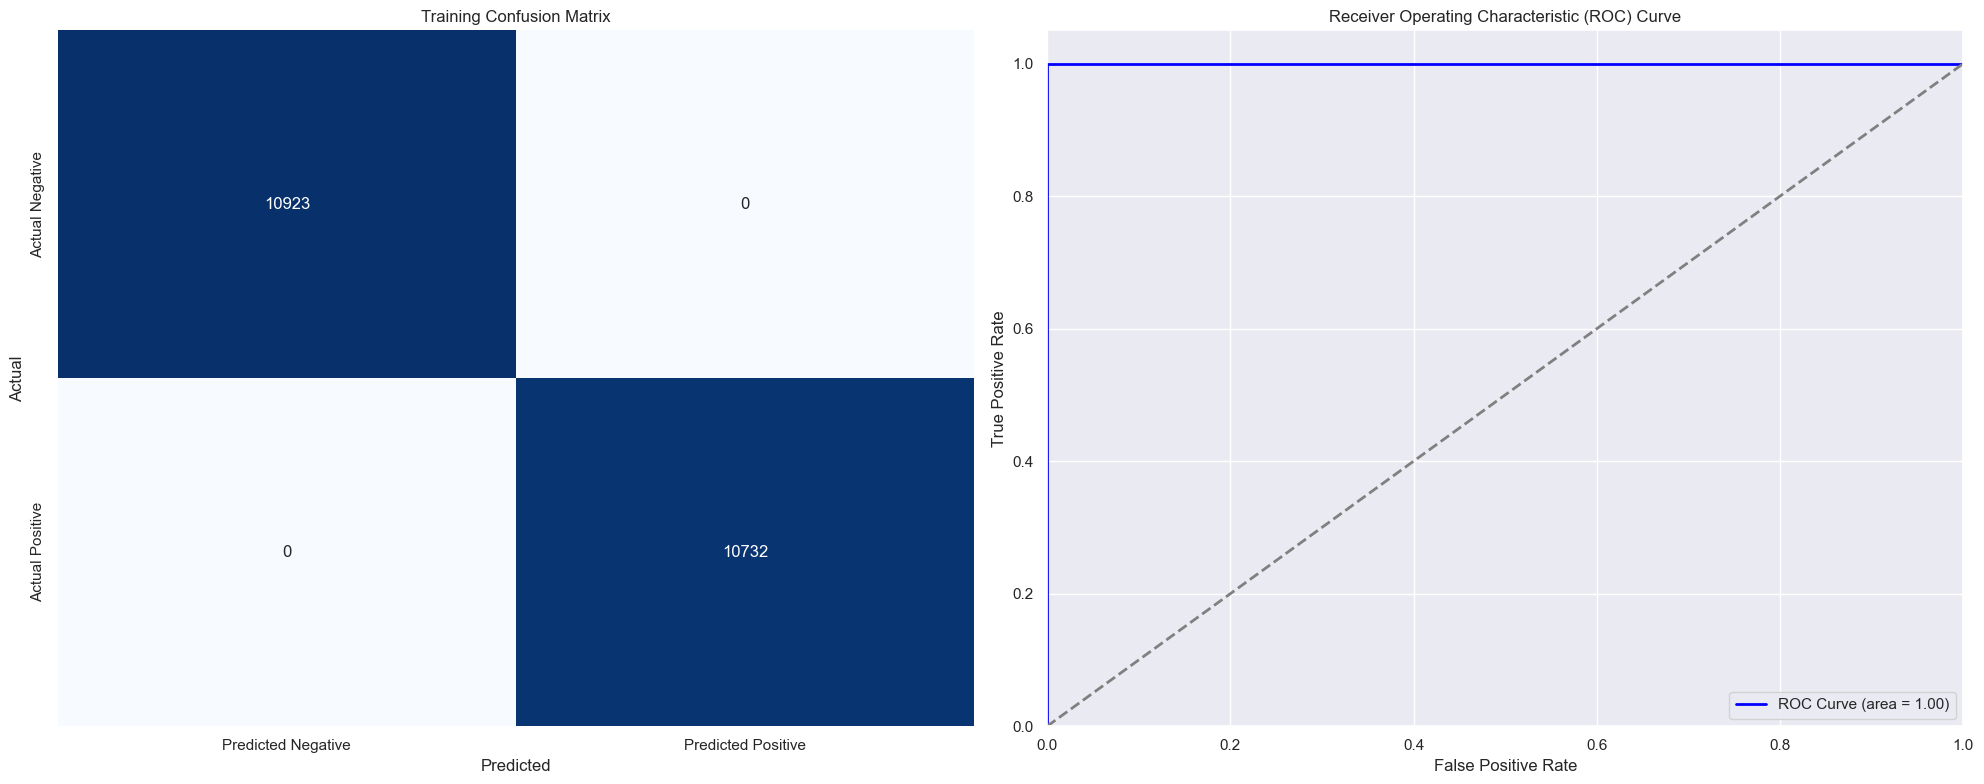

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [44]:
# initialize variables
algorithm = 'KNN'
desc = f'{algorithm} - {msg}'
model = 'knn_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.68      0.77      2731
        True       0.74      0.90      0.81      2683

    accuracy                           0.79      5414
   macro avg       0.81      0.79      0.79      5414
weighted avg       0.81      0.79      0.79      5414



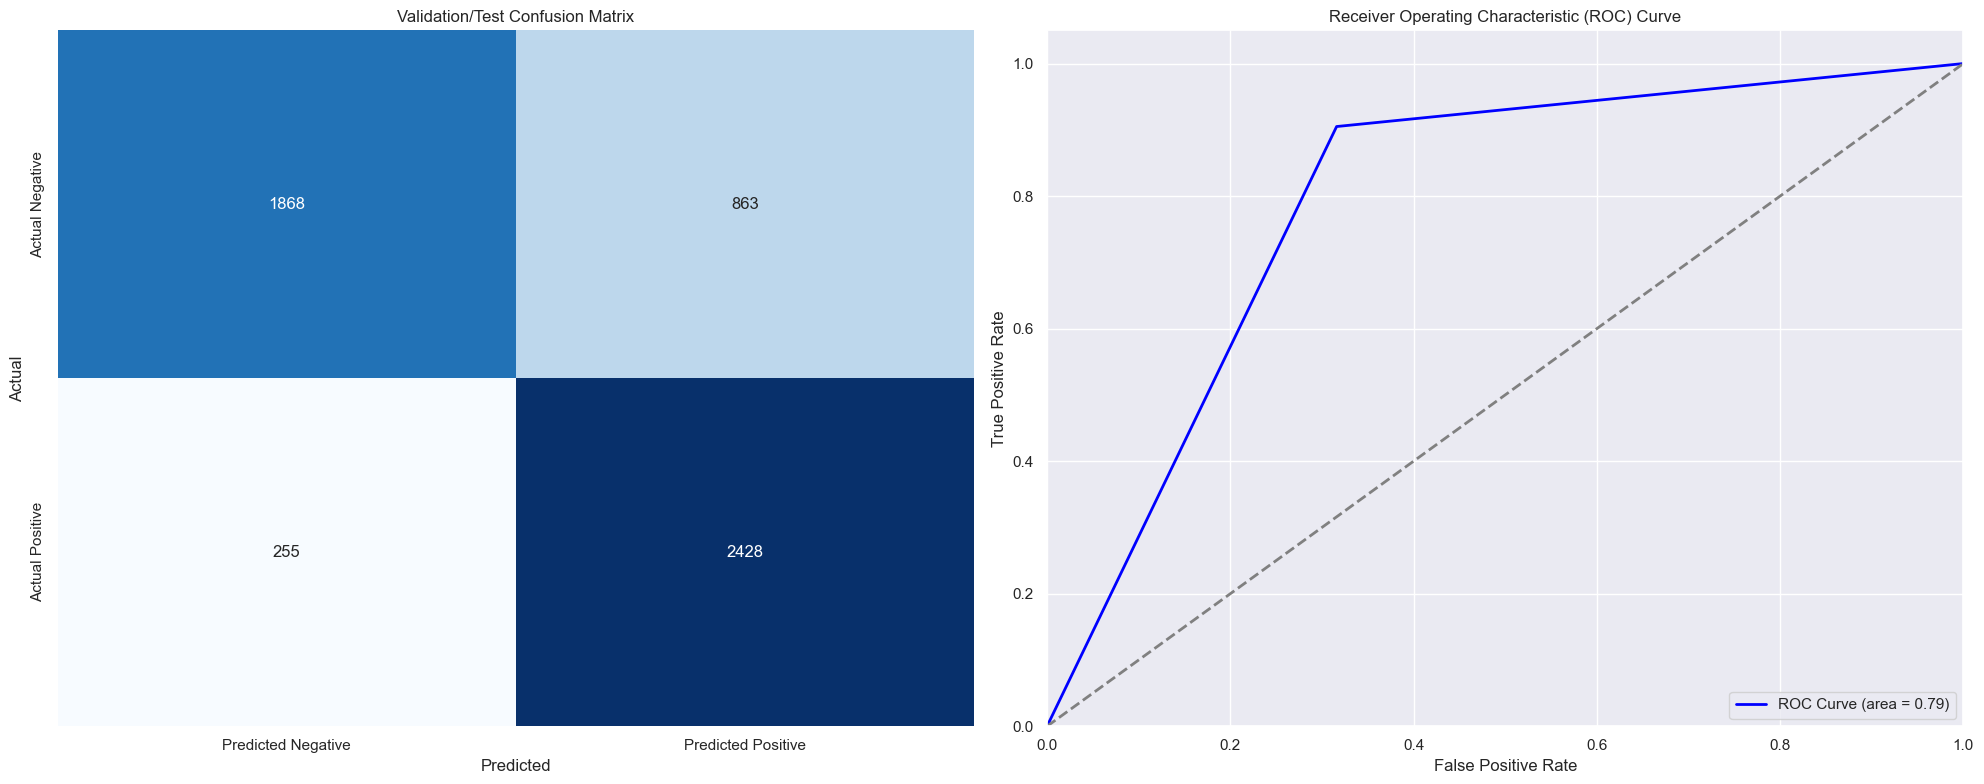

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478


In [45]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Note:  Clearly Overfitting!

### AdaBoostClassifier

In [46]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the search space
search_space = parms.ada_search_space()

# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
Model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# Hyper-Parameter tuning
ada_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, 'f1', n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = ada_fit

Best parameters found: OrderedDict([('learning_rate', 1.741157627268389), ('n_estimators', 403)])
Best score achieved: 0.855908250402322

Current Model Parameters:
 AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=1.741157627268389, n_estimators=403,
                   random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.71      0.82     10923
        True       0.77      0.97      0.86     10732

    accuracy                           0.84     21655
   macro avg       0.86      0.84      0.84     21655
weighted avg       0.87      0.84      0.84     21655



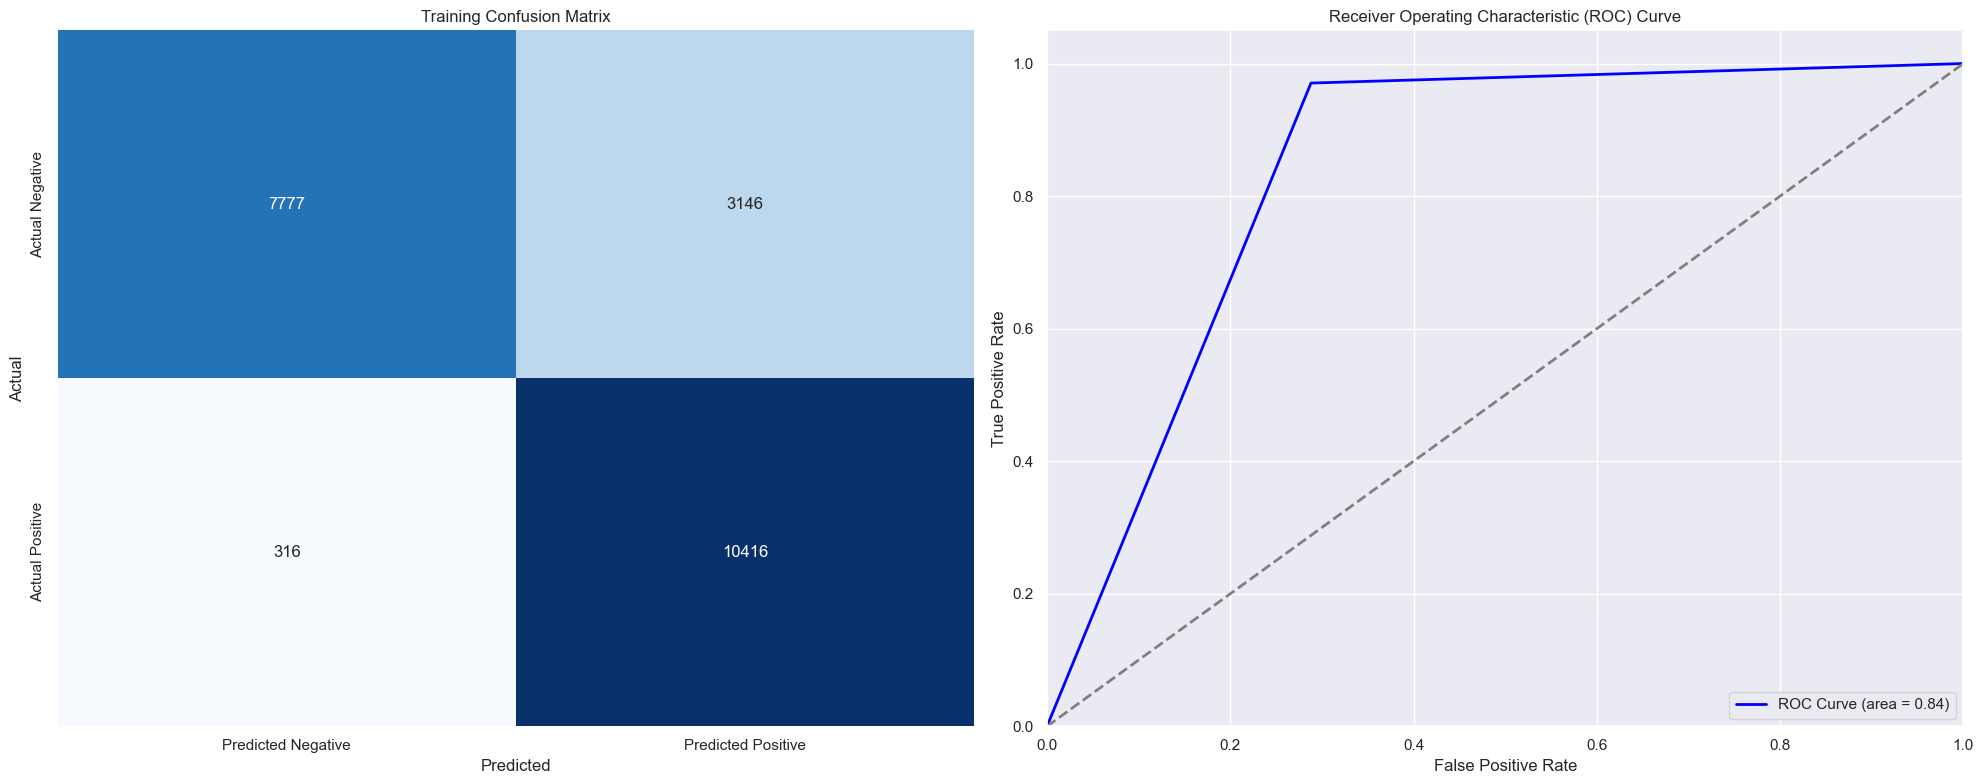

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270


In [47]:
# initialize variables
algorithm = 'AdaBoost'
desc = f'{algorithm} - {msg}'
model = 'ada_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.70      0.81      2731
        True       0.76      0.97      0.85      2683

    accuracy                           0.83      5414
   macro avg       0.86      0.84      0.83      5414
weighted avg       0.86      0.83      0.83      5414



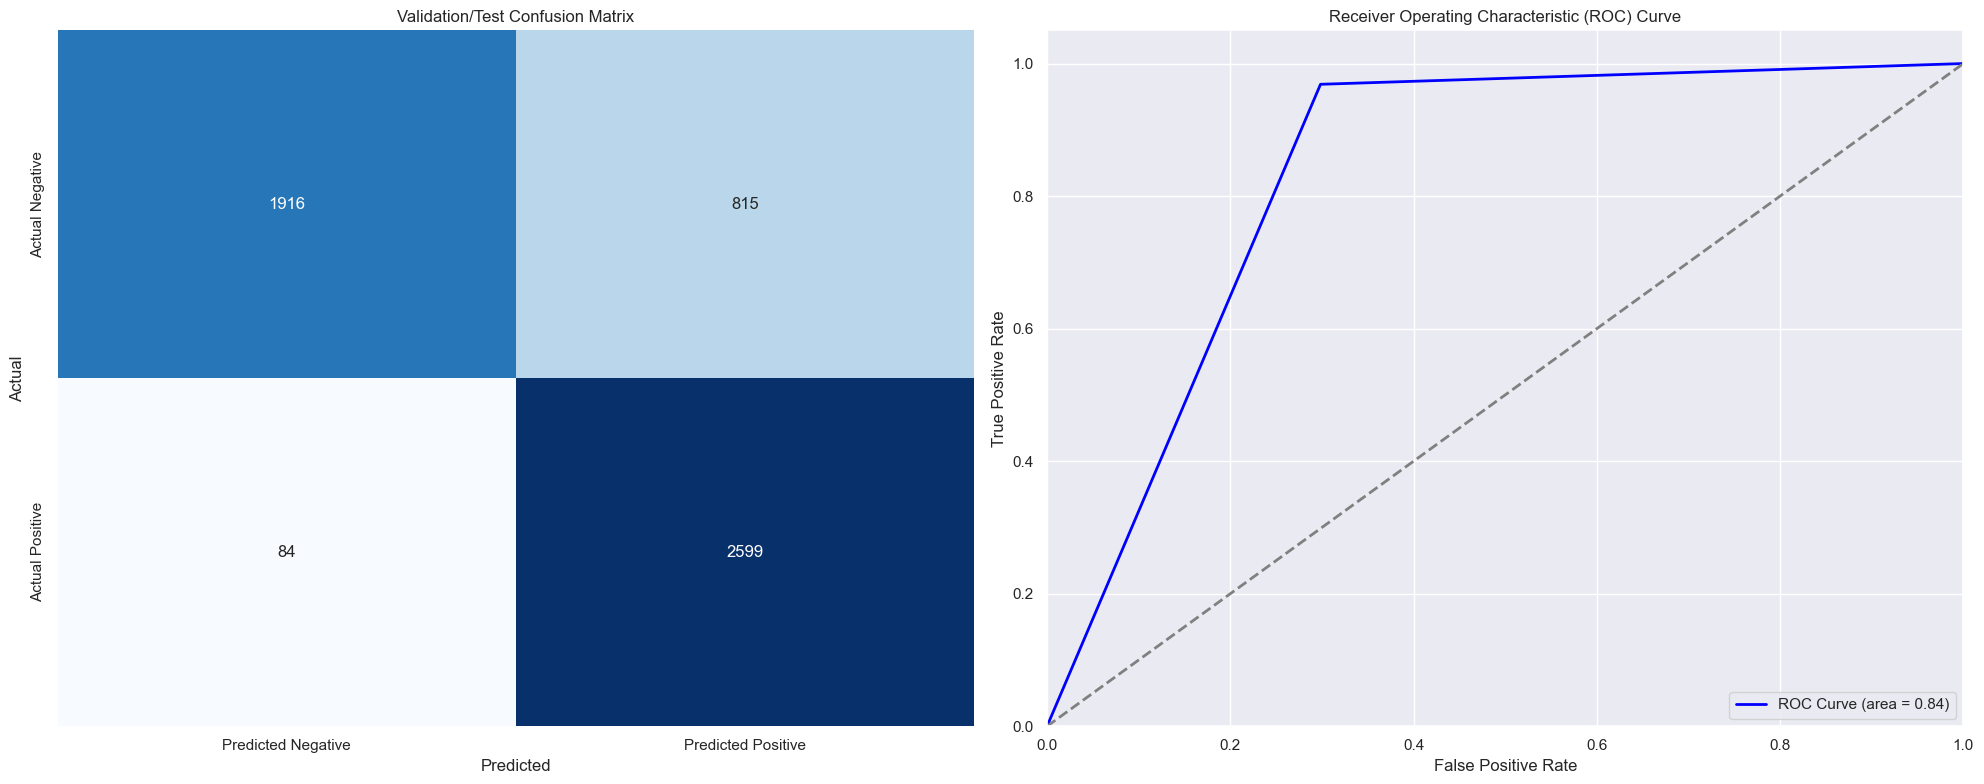

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133


In [48]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

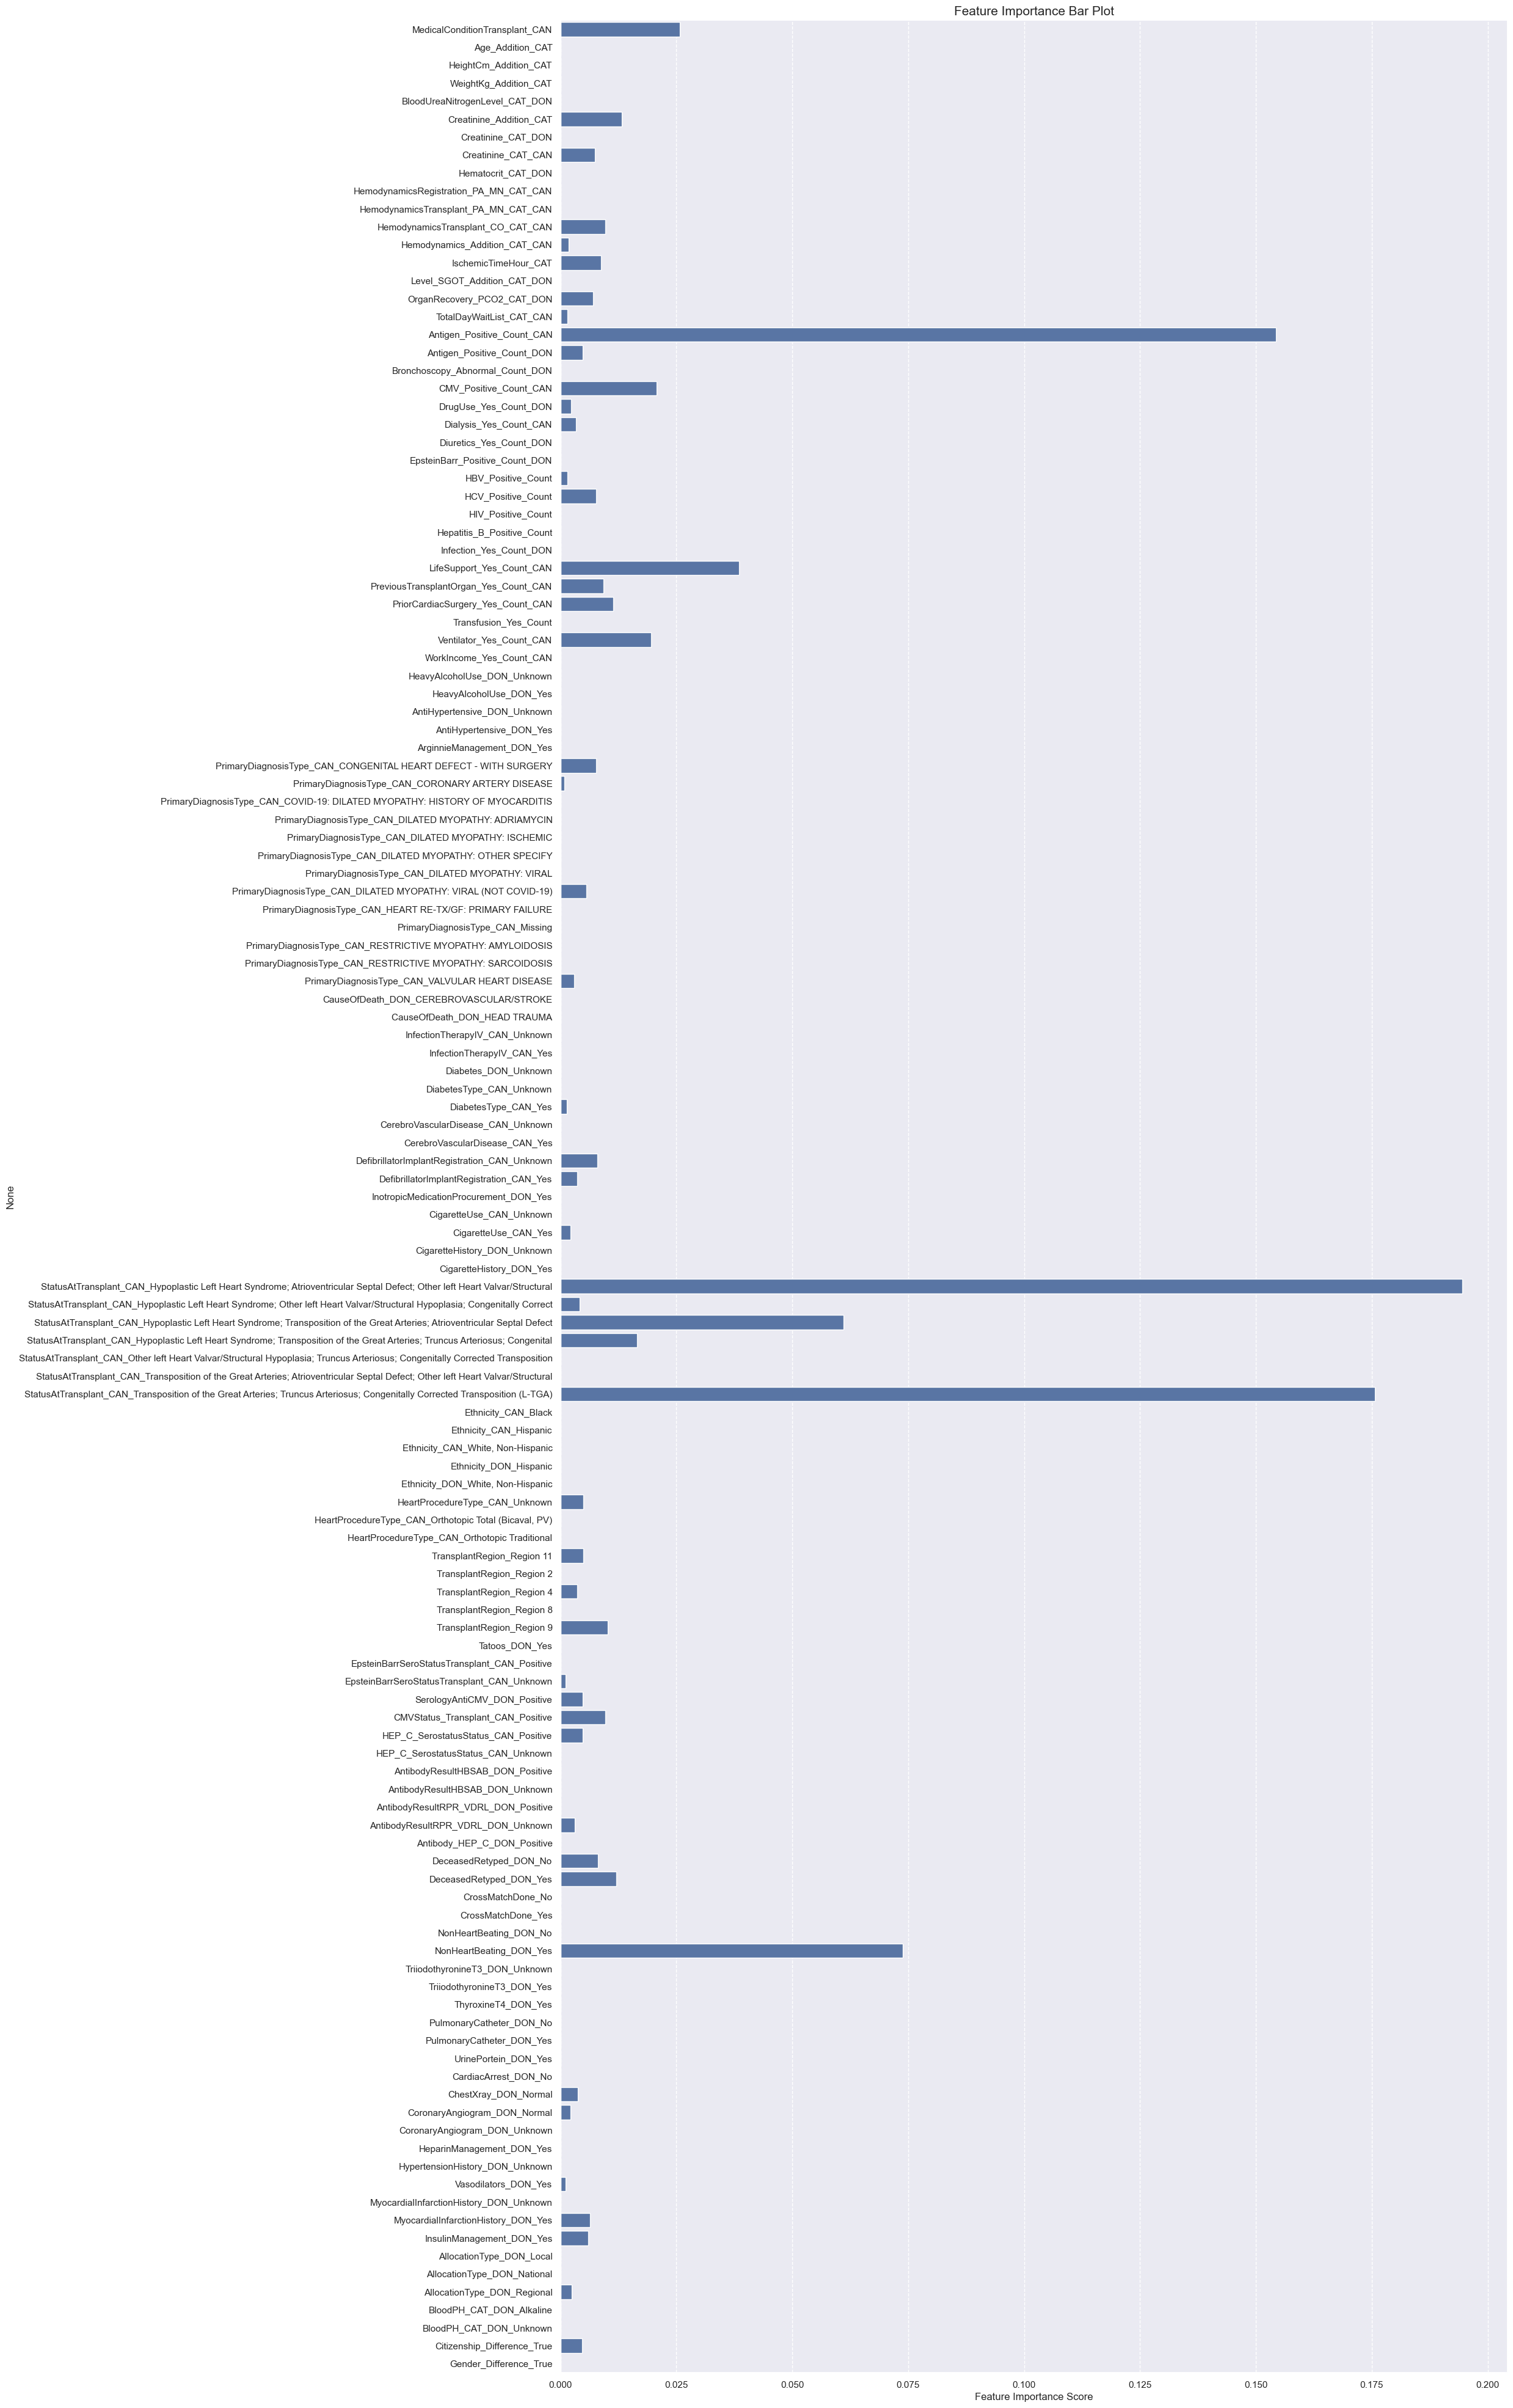

In [49]:
df_ada = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [50]:
df_ada.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.194497
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.175707
Antigen_Positive_Count_CAN,0.154377
NonHeartBeating_DON_Yes,0.073894
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.061017
LifeSupport_Yes_Count_CAN,0.038564
MedicalConditionTransplant_CAN,0.025684
CMV_Positive_Count_CAN,0.020788
Ventilator_Yes_Count_CAN,0.019612
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital,0.016512


### Stacking Classifier
- Both AdaBoost and XGBoost are boosting algorithms, but they have key differences:
    - AdaBoost: Focuses on reducing bias by reweighting misclassified samples, works well with weak learners.
        - AdaBoost → Handles noisy datasets and works well with simpler decision stumps. 
    - XGBoost: A gradient boosting algorithm that minimizes loss efficiently using second-order derivatives and feature importance techniques.
        - XGBoost → Captures complex patterns, handles missing values, and optimizes performance.
    - Random Forest is a bagging-based algorithm that reduces variance and is more robust to noise.

In [51]:
# import library
from sklearn.ensemble import StackingClassifier

# best model
AdaModel = ada_fit
XGBModel = xgb_fit

# filt model
AdaModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('adaboost', AdaModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# Fit the stacking ensemble
stack_AdaXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.77      0.86     10923
        True       0.81      0.99      0.89     10732

    accuracy                           0.88     21655
   macro avg       0.90      0.88      0.88     21655
weighted avg       0.90      0.88      0.88     21655



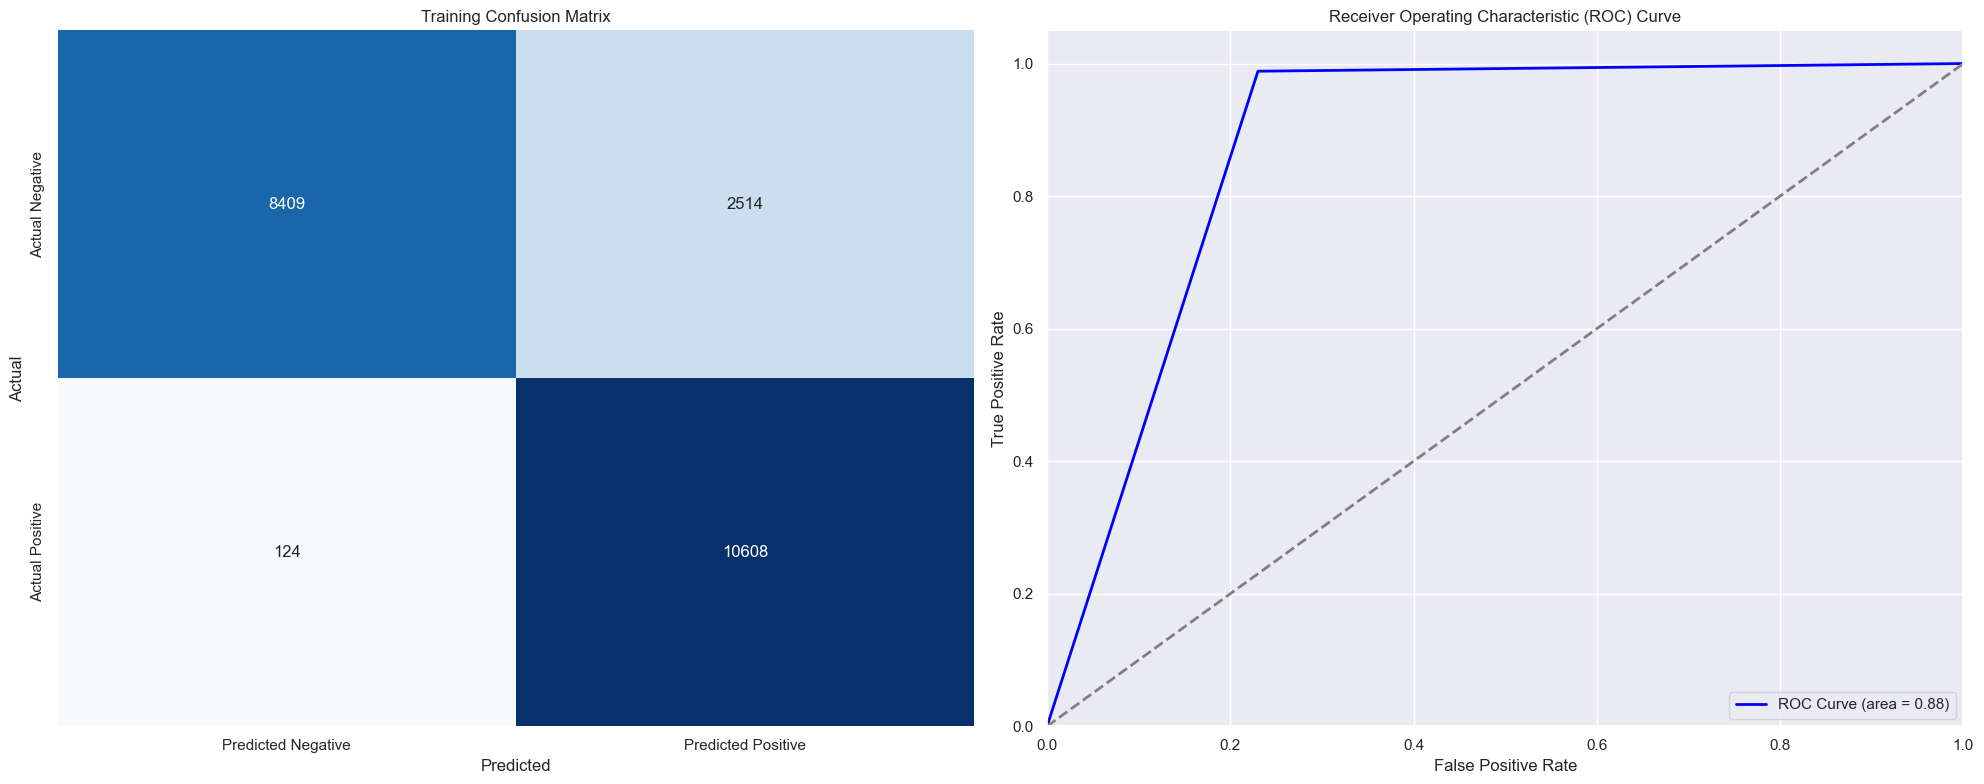

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133


In [52]:
# initialize variables
algorithm = 'Stacking(AdaBoost & XGBoost)'
desc = f'{algorithm} - {msg}'
model = 'stack_AdaXgb'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, stack_AdaXgb, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.70      0.81      2731
        True       0.76      0.97      0.85      2683

    accuracy                           0.84      5414
   macro avg       0.86      0.84      0.83      5414
weighted avg       0.86      0.84      0.83      5414



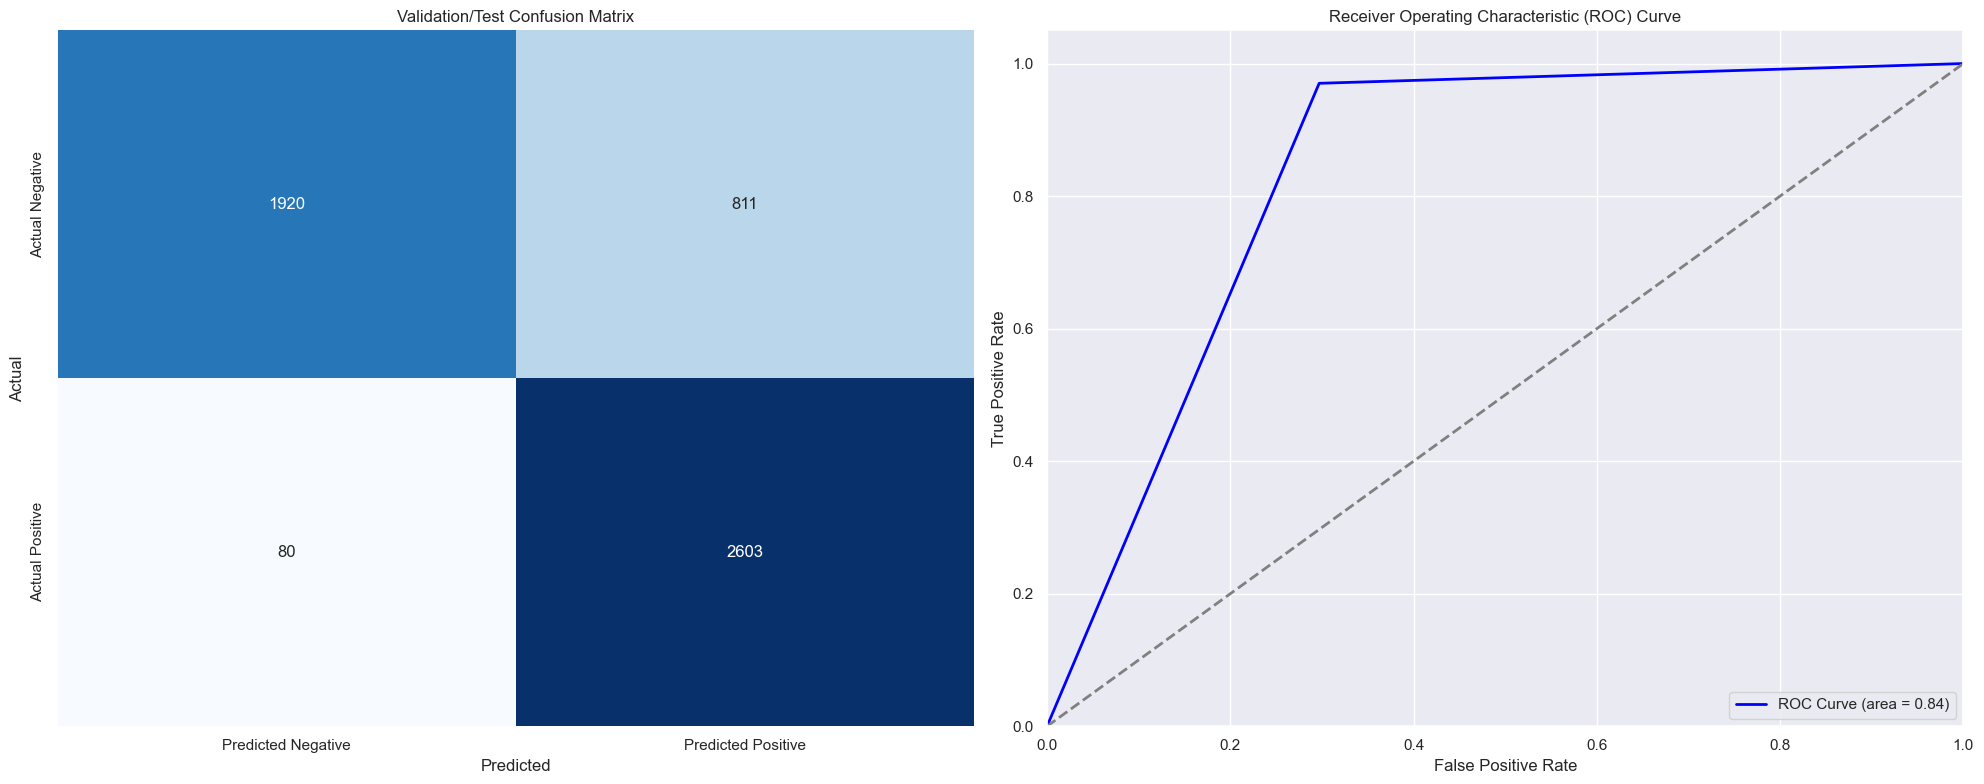

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133


In [53]:
# initialize variables
data_type = 'Validation/test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, stack_AdaXgb, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

In [54]:
RFCModel = rfc_fit
XGBModel = xgb_fit

# filt model
RFCModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('randomforest', RFCModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# fit the stacking ensemble
stack_RfcXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.77      0.86     10923
        True       0.81      0.99      0.89     10732

    accuracy                           0.88     21655
   macro avg       0.89      0.88      0.87     21655
weighted avg       0.90      0.88      0.87     21655



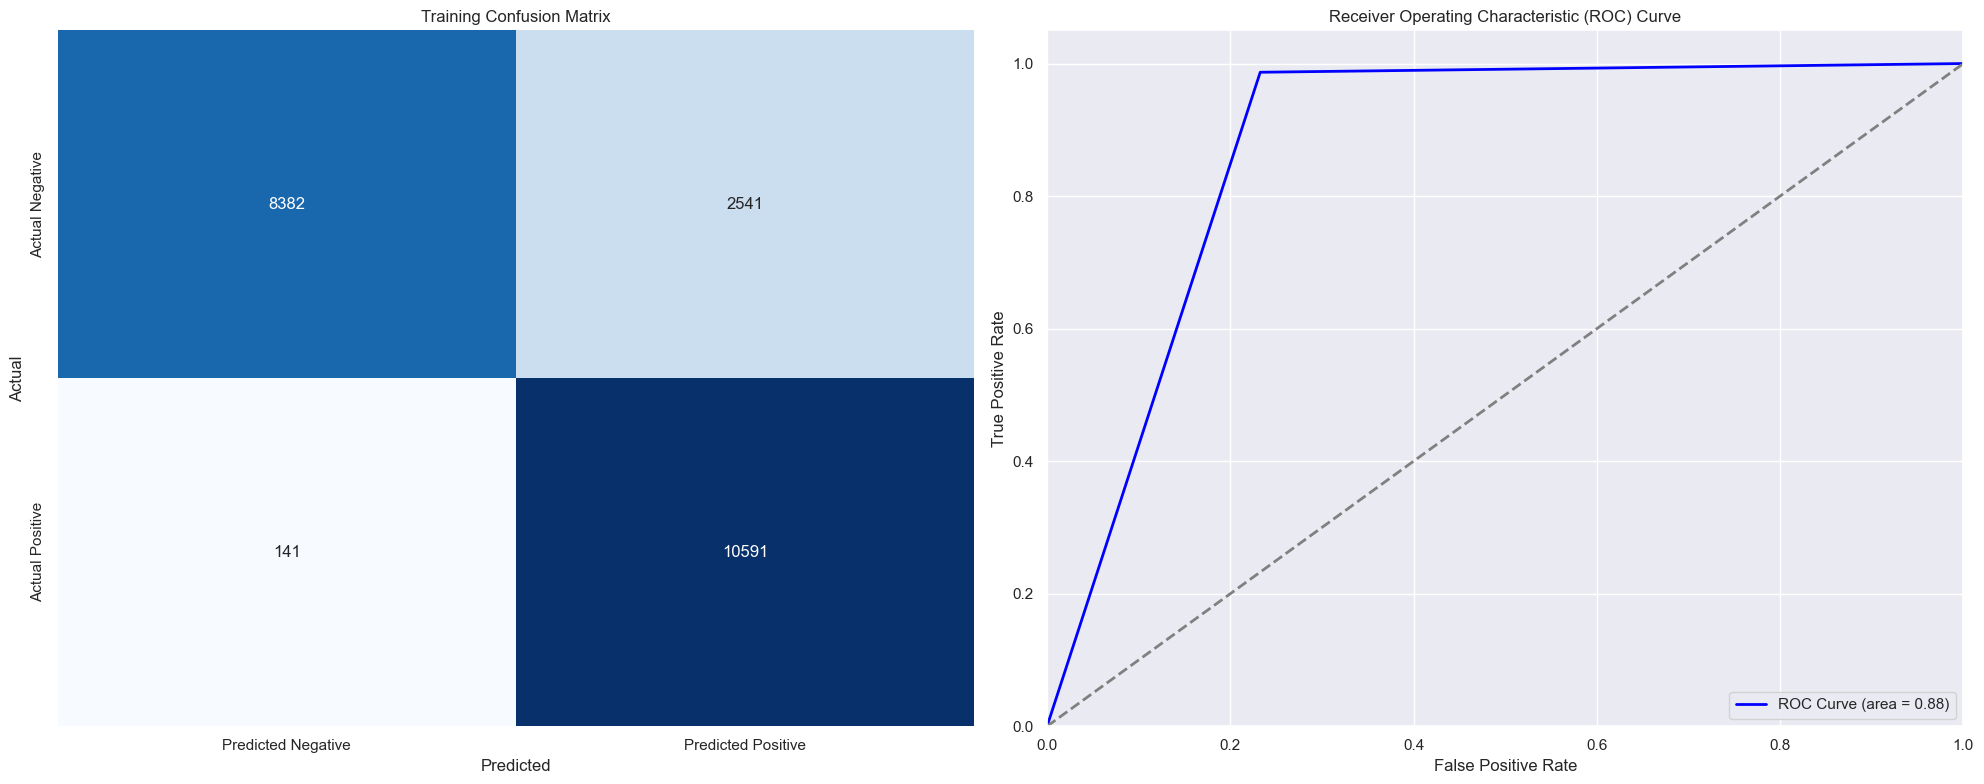

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133


In [55]:
# initialize variables
algorithm = 'Stacking(RandomForest & XGBoost)'
desc = f'{algorithm} - {msg}'
model = 'stack_AdaXgb'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, stack_RfcXgb, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.71      0.81      2731
        True       0.76      0.97      0.85      2683

    accuracy                           0.84      5414
   macro avg       0.86      0.84      0.83      5414
weighted avg       0.86      0.84      0.83      5414



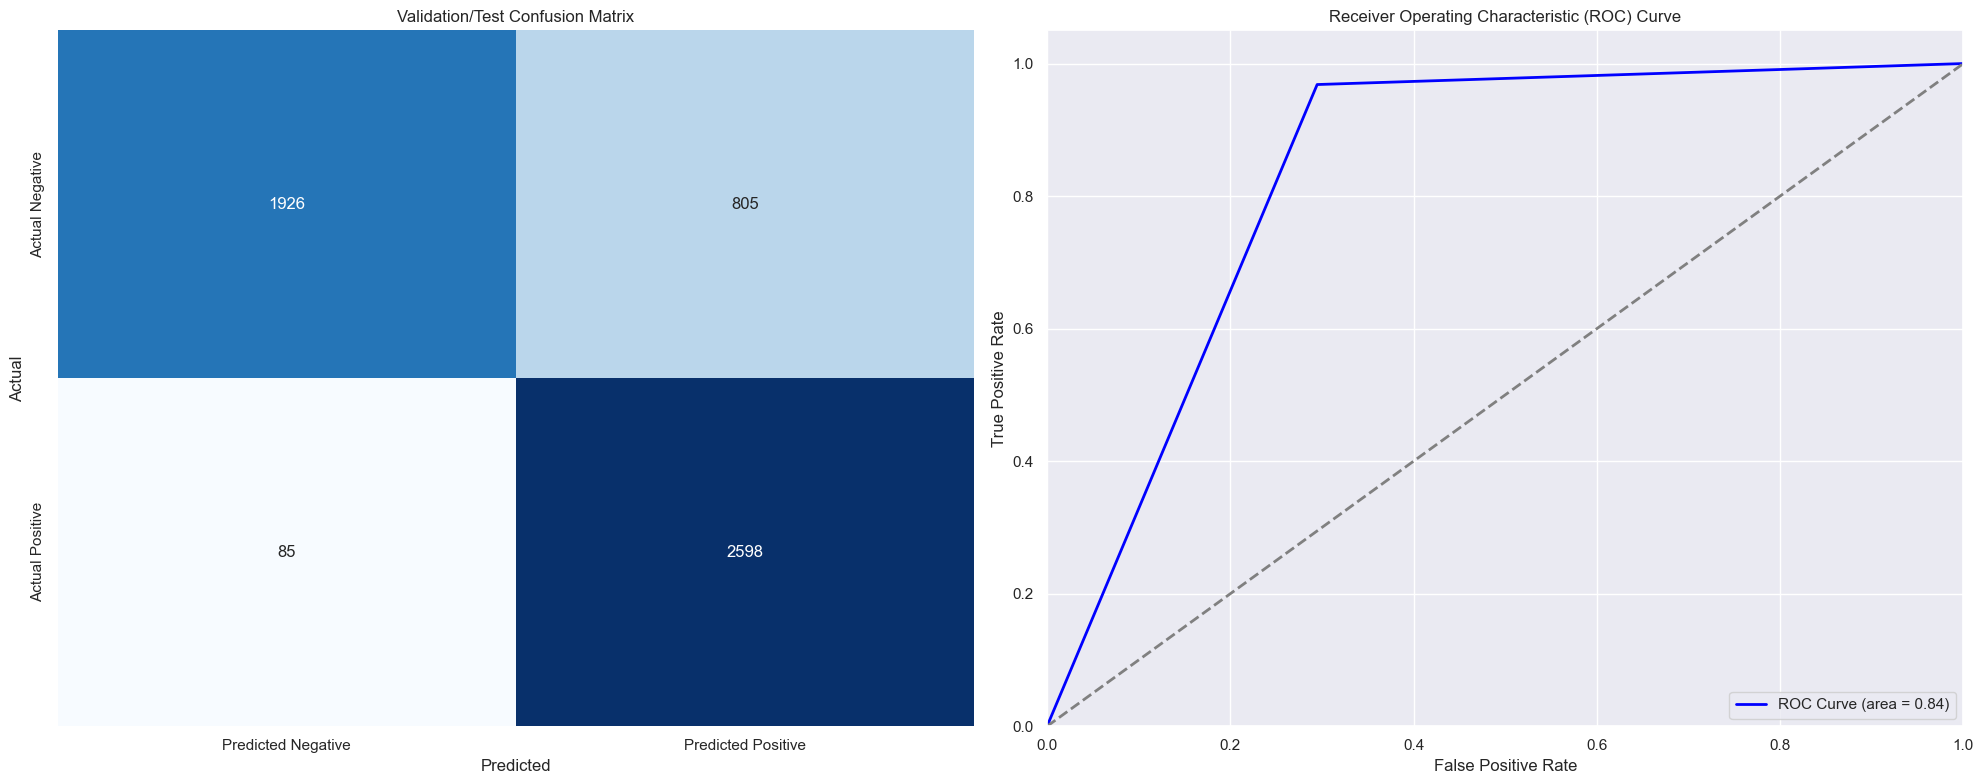

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.847287,0.977264,0.863814,0.767636,0.773965,0.719583,0.848423
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.839483,0.969344,0.856849,0.759406,0.767749,0.711892,0.840618
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.858508,0.990682,0.874055,0.779326,0.781995,0.728646,0.859664
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
6,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Training,0.840129,0.970555,0.857496,0.760006,0.768028,0.711984,0.841270
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133


In [56]:
# initialize variables
data_type = 'Validation/test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, stack_RfcXgb, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=threshold)
df_classfication

### Overall Model Performance

In [57]:
# display
filtered_df = df_classfication[df_classfication.DataType != 'Training']
filtered_df.sort_values(by=['Accuracy', 'ROC_AUC_Score'], ascending=False)

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.839121,0.986955,0.858764,0.756596,0.760046,0.693885,0.840420
13,Stacking(RandomForest & XGBoost),stack_AdaXgb,Stacking(RandomForest & XGBoost) - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835611,0.968319,0.853763,0.754957,0.763444,0.705236,0.836778
11,Stacking(AdaBoost & XGBoost),stack_AdaXgb,Stacking(AdaBoost & XGBoost) - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835427,0.970183,0.853863,0.754491,0.762449,0.703039,0.836611
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.835057,0.968692,0.853390,0.754256,0.762617,0.703772,0.836232
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.834688,0.968692,0.853110,0.753823,0.762170,0.703039,0.835865
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.833949,0.968692,0.852550,0.752958,0.761277,0.701575,0.835133
7,KNN,knn_fit,KNN - 2011-2016: Discretization - Bayesian Search: Scoring F1 - Select K-Best p_value < 0.05 0.05 removed - SWAP,Validation/test,0.793498,0.904957,0.812856,0.714750,0.737770,0.683999,0.794478


### Save Model to Disk

In [58]:
import joblib

# save the model to a file
print(joblib.dump(xgb_fit, '../Models/XGBmodel_Discretization_BayesianSearch_SKBest_Swap.joblib'))
print(joblib.dump(lrc_fit, '../Models/LRmodel_Discretization_BayesianSearch_SKBest_Swap.joblib'))
print(joblib.dump(rfc_fit	, '../Models/RFmodel_Discretization_BayesianSearch_SKBest_Swap.joblib'))
print(joblib.dump(ada_fit, '../Models/ADAmodel_Discretization_BayesianSearch_SKBest_Swap.joblib'))

# write dataset - # X_train, y_train, X_test, y_test files
uf.write_to_file(X_train, 'X_train_SKBest_Swap',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_train, 'y_train_SKBest_Swap',path='../Data/XyData/', format='pkl')
uf.write_to_file(X_test, 'X_test_SKBest_Swap',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_test, 'y_test_SKBest_Swap',path='../Data/XyData/', format='pkl')

# load the model from the file
# loaded_model = joblib.load('../Models/KNN_Threshold.joblib')

['../Models/XGBmodel_Discretization_BayesianSearch_SKBest_Swap.joblib']
['../Models/LRmodel_Discretization_BayesianSearch_SKBest_Swap.joblib']
['../Models/RFmodel_Discretization_BayesianSearch_SKBest_Swap.joblib']
['../Models/ADAmodel_Discretization_BayesianSearch_SKBest_Swap.joblib']
21,655 records written to ../Data/XyData/X_train_SKBest_Swap.pkl
21,655 records written to ../Data/XyData/y_train_SKBest_Swap.pkl
5,414 records written to ../Data/XyData/X_test_SKBest_Swap.pkl
5,414 records written to ../Data/XyData/y_test_SKBest_Swap.pkl
